# CSCN8020 Assignment 3  
## Deep Q-Network Control of the Unitree G1 Left Elbow

**Student:** Emmanuel Ihejiamaizu  
**Student ID:** 9080005  
**Course:** CSCN8020 Reinforcement Learning  
**Repository:** `https://github.com/chooksemmanuel/CSCN8020_Assignment3`  
**Clone URL:** `https://github.com/chooksemmanuel/CSCN8020_Assignment3.git`

This notebook documents the completed student-written Deep Q-Network solution, the controlled comparison of two epsilon-decay configurations, the benchmark against the rule-based policy, and the reproducibility commands for training, evaluation, checkpoint loading, and rendering.


## 1. Project Objective

The assignment extends the validated Unitree G1 MuJoCo elbow-control workshop into a reinforcement-learning task. The agent observes the elbow state and target error, then chooses one of three discrete actions:

- decrease the elbow target,
- hold the current target,
- increase the elbow target.

A PyTorch Deep Q-Network learns this policy from replayed transitions while a separate target network stabilizes the temporal-difference targets.


<a id="math-to-code-mdp"></a>

### 1.1 Reinforcement-Learning Task and MDP Formulation

<!-- MATH-TO-CODE-MDP-SECTION-V1 -->

The Unitree G1 left-elbow task is modeled as a discounted Markov Decision Process:

\[
\mathcal{M}=(\mathcal{S},\mathcal{A},P,R,\gamma)
\]

where:

- \(\mathcal{S}\) is the observation/state space,
- \(\mathcal{A}\) is the discrete action space,
- \(P(s_{t+1}\mid s_t,a_t)\) is the transition process produced by the PD controller and MuJoCo physics,
- \(R(s_t,a_t,s_{t+1})\) is the reward function, and
- \(\gamma=0.95\) is the discount factor used by the DQN.

#### State / Observation

At environment step \(t\), the DQN receives the four-value observation

\[
s_t=
\begin{bmatrix}
q_t \\
\dot q_t \\
q_{\mathrm{goal}} \\
q_{\mathrm{goal}}-q_t
\end{bmatrix}
\]

where:

- \(q_t\) is the current left-elbow angle,
- \(\dot q_t\) is the current left-elbow angular velocity,
- \(q_{\mathrm{goal}}\) is the target angle for the episode, and
- \(e_t=q_{\mathrm{goal}}-q_t\) is the signed angle error.

This is implemented by `G1ElbowTargetEnv._get_observation()` in
`src/g1_rl/g1_elbow_env.py`, which returns

```python
[
    elbow_angle,
    elbow_velocity,
    self.goal_angle,
    angle_error,
]
```

During assignment training, `src/train_dqn.py` explicitly constructs the
environment with

```python
goal_range=(-0.8, 0.8)
```

so the formal training-goal distribution is

\[
q_{\mathrm{goal}}\sim\mathcal{U}(-0.8,0.8).
\]

#### Discrete Action Space

The action space is

\[
\mathcal{A}=\{0,1,2\}
\]

with

\[
a_t=
\begin{cases}
0 & \text{decrease the internal controller target},\\
1 & \text{hold the internal controller target},\\
2 & \text{increase the internal controller target}.
\end{cases}
\]

Let \(\Delta q=0.08\) rad. The controller target is updated as

\[
q^{\mathrm{ctrl}}_{t+1}
=
\operatorname{clip}
\left(
q^{\mathrm{ctrl}}_t+\delta(a_t),
q_{\min},
q_{\max}
\right),
\]

where

\[
\delta(a_t)=
\begin{cases}
-\Delta q,&a_t=0,\\
0,&a_t=1,\\
+\Delta q,&a_t=2.
\end{cases}
\]

This maps to the action constants `ACTION_DECREASE`, `ACTION_HOLD`,
and `ACTION_INCREASE`, and to `_apply_action()` in
`src/g1_rl/g1_elbow_env.py`.

#### Transition Dynamics

The DQN does not output actuator torque directly. After the discrete action
changes the internal controller target, the low-level controller computes

\[
\tau_{\mathrm{PD}}
=
K_p(q^{\mathrm{desired}}-q_t)-K_d\dot q_t.
\]

MuJoCo bias-force compensation is then added:

\[
\tau_{\mathrm{command}}
=
\operatorname{clip}
\left(
\tau_{\mathrm{PD}}+\tau_{\mathrm{bias}},
u_{\min},
u_{\max}
\right).
\]

The environment advances MuJoCo for `frame_skip = 10` physics frames and then
returns \(s_{t+1}\). Therefore, the transition distribution
\(P(s_{t+1}\mid s_t,a_t)\) is represented implicitly by the controller and
MuJoCo simulation rather than by a manually specified transition table.

#### Reward Function

After the physical transition, define the next-state error as

\[
e_{t+1}=q_{\mathrm{goal}}-q_{t+1}.
\]

The implemented reward is

\[
\begin{aligned}
r_{t+1}
={}&-|e_{t+1}| \\
&+\mathbb{1}\left(|e_{t+1}|\le 0.04\right)\\
&-0.05\,
\mathbb{1}\left(|e_{t+1}|\le 0.04 \land a_t\ne1\right)\\
&+10\,
\mathbb{1}\left(\mathrm{terminated}_{t+1}\right).
\end{aligned}
\]

Here, \(\mathbb{1}(\cdot)\) is an indicator function that equals 1 when its
condition is true and 0 otherwise.

The terms have the following purposes:

1. \(-|e_{t+1}|\) provides dense shaping toward the goal.
2. \(+1\) rewards entering the success-tolerance region.
3. \(-0.05\) discourages unnecessary DECREASE or INCREASE actions once the
   elbow is already close to the goal.
4. \(+10\) rewards successful completion.

This equation maps directly to `_calculate_reward()` and the terminal-success
bonus in `G1ElbowTargetEnv.step()`.

#### Termination and Truncation

A true task termination occurs when

\[
|e_t|\le0.04
\]

for at least 8 consecutive environment steps:

\[
\mathrm{terminated}_t
=
\mathbb{1}\left(\mathrm{success\_streak}_t\ge8\right).
\]

A time-limit truncation occurs when

\[
\mathrm{truncated}_t
=
\mathbb{1}\left(\mathrm{episode\_step}_t\ge150\right).
\]

The distinction matters during DQN learning: a true termination prevents
bootstrapping, while a time-limit truncation still permits bootstrapping from
the next state.

#### Discounted Return and Learning Objective

The return from time \(t\) is

\[
G_t
=
\sum_{k=0}^{\infty}\gamma^k r_{t+k+1},
\qquad
\gamma=0.95.
\]

The DQN approximates the optimal action-value function

\[
Q^*(s,a)
=
\max_{\pi}
\mathbb{E}_{\pi}\left[G_t\mid s_t=s,a_t=a\right].
\]

Its network maps the four-value observation to three action values:

\[
\mathbb{R}^4
\longrightarrow
\mathbb{R}^3,
\qquad
s_t
\longmapsto
\begin{bmatrix}
Q(s_t,0)\\
Q(s_t,1)\\
Q(s_t,2)
\end{bmatrix}.
\]

During greedy action selection,

\[
a_t=\arg\max_{a\in\{0,1,2\}}Q_{\mathrm{online}}(s_t,a).
\]

During training, this greedy action is combined with epsilon-greedy
exploration. The Bellman target, terminal mask, and Huber loss are mapped to
the implementation in a later executable section of this notebook.


<a id="math-to-code-mapping"></a>

### 1.2 Exact Math-to-Code Mapping

<!-- MATH-TO-CODE-MAPPING-TABLE-V1 -->

The table below maps each mathematical element of the MDP and DQN update to
the exact implementation used in this assignment.

| Concept | Mathematical form | Exact implementation | Source location |
|---|---|---|---|
| Training goal distribution | \(q_{\mathrm{goal}}\sim\mathcal{U}(-0.8,0.8)\) | `G1ElbowTargetEnv(goal_angle=None, goal_range=(-0.8, 0.8))` | `src/train_dqn.py`, environment construction |
| State / observation | \(s_t=[q_t,\dot q_t,q_{\mathrm{goal}},q_{\mathrm{goal}}-q_t]\) | `np.array([elbow_angle, elbow_velocity, self.goal_angle, angle_error], dtype=np.float32)` | `G1ElbowTargetEnv._get_observation()` |
| Action set | \(\mathcal{A}=\{0,1,2\}\) | `spaces.Discrete(3)` | `G1ElbowTargetEnv.__init__()` |
| Action meanings | \(0=\mathrm{decrease},\ 1=\mathrm{hold},\ 2=\mathrm{increase}\) | `ACTION_DECREASE = 0`, `ACTION_HOLD = 1`, `ACTION_INCREASE = 2` | `src/g1_rl/g1_elbow_env.py` |
| Controller-target update | \(q^{\mathrm{ctrl}}_{t+1}=\operatorname{clip}(q^{\mathrm{ctrl}}_t+\delta(a_t),q_{\min},q_{\max})\) | subtract `0.08`, hold, or add `0.08`, followed by `np.clip(...)` | `G1ElbowTargetEnv._apply_action()` |
| PD torque | \(\tau_{\mathrm{PD}}=K_p(q^{\mathrm{desired}}-q_t)-K_d\dot q_t\) | `kp * (target_angle - current_angle) - kd * current_velocity` | `G1ElbowTargetEnv._calculate_pd_torque()` |
| Bias compensation | \(\tau_{\mathrm{command}}=\operatorname{clip}(\tau_{\mathrm{PD}}+\tau_{\mathrm{bias}},u_{\min},u_{\max})\) | `pd_torque + self.data.qfrc_bias[qvel_index]`, then actuator-range clipping | `G1ElbowTargetEnv._apply_controller()` |
| Transition | \(P(s_{t+1}\mid s_t,a_t)\) | apply action, run PD control and `mujoco.mj_step(...)` for `frame_skip=10`, then call `_get_observation()` | `G1ElbowTargetEnv.step()` |
| Next-state error | \(e_{t+1}=q_{\mathrm{goal}}-q_{t+1}\) | `absolute_error = abs(float(observation[3]))` | `G1ElbowTargetEnv.step()` |
| Dense reward | \(-|e_{t+1}|\) | `reward = -absolute_error` | `G1ElbowTargetEnv._calculate_reward()` |
| Tolerance bonus | \(+\mathbb{1}(|e_{t+1}|\le0.04)\) | `if absolute_error <= self.success_tolerance: reward += 1.0` | `G1ElbowTargetEnv._calculate_reward()` |
| Non-HOLD penalty | \(-0.05\,\mathbb{1}(|e_{t+1}|\le0.04\land a_t\ne1)\) | subtract `0.05` when close and `action != ACTION_HOLD` | `G1ElbowTargetEnv._calculate_reward()` |
| Success bonus | \(+10\,\mathbb{1}(\mathrm{terminated}_{t+1})\) | `if terminated: reward += 10.0` | `G1ElbowTargetEnv.step()` |
| True termination | \(\mathrm{terminated}_t=\mathbb{1}(\mathrm{success\_streak}_t\ge8)\) | compare `success_streak` with `required_success_steps` | `G1ElbowTargetEnv.step()` |
| Time-limit truncation | \(\mathrm{truncated}_t=\mathbb{1}(\mathrm{episode\_step}_t\ge150)\) | compare `episode_step` with `maximum_episode_steps` | `G1ElbowTargetEnv.step()` |
| Q-network | \(Q_\theta:\mathbb{R}^4\rightarrow\mathbb{R}^3\) | `Linear(4,64) -> ReLU -> Linear(64,64) -> ReLU -> Linear(64,3)` | `src/g1_rl/dqn/q_network.py` |
| Epsilon-greedy policy | random action with probability \(\epsilon\), otherwise \(\arg\max_aQ_\theta(s_t,a)\) | random branch using `self._random.random() < self.epsilon`; greedy branch using `q_values.argmax(...)` | `DQNAgent.select_action()` |
| Replay transition | \((s_t,a_t,r_{t+1},s_{t+1},\mathrm{terminated},\mathrm{truncated})\) | `agent.store_transition(...)` after `env.step(action)` | `src/train_dqn.py` |
| Selected online Q-value | \(Q_\theta(s_t,a_t)\) | `self.online_network(batch.states).gather(1, batch.actions)` | `DQNAgent.optimize_model()` |
| Target-network next value | \(\max_{a'}Q_{\theta^-}(s_{t+1},a')\) | `self.target_network(batch.next_states).max(...).values` inside `torch.no_grad()` | `DQNAgent.optimize_model()` |
| Bootstrap mask | \(m_t=1-\mathbb{1}(\mathrm{terminated}_{t+1})\) | `bootstrap_mask = (~batch.terminated).to(dtype=torch.float32)` | `DQNAgent.optimize_model()` |
| Bellman target | \(y_t=r_{t+1}+\gamma m_t\max_{a'}Q_{\theta^-}(s_{t+1},a')\) | `batch.rewards + gamma * bootstrap_mask * next_q_values` | `DQNAgent.optimize_model()` |
| Discount factor | \(\gamma=0.95\) | `gamma: float = 0.95` | `DQNConfig` |
| DQN loss | \(L_t=\operatorname{Huber}(Q_\theta(s_t,a_t),y_t)\) | `nn.functional.smooth_l1_loss(selected_q_values, bellman_targets)` | `DQNAgent.optimize_model()` |
| Gradient clipping | \(\lVert\nabla_\theta L\rVert\le10\) after clipping | `clip_grad_norm_(..., max_norm=10.0)` | `DQNAgent.optimize_model()` |
| Target synchronization | \(\theta^-\leftarrow\theta\) every 250 optimization steps | `target_network.load_state_dict(online_network.state_dict())` | `DQNAgent.sync_target_network()` |
| Epsilon decay | \(\epsilon_{k+1}=\max(0.05,\epsilon_k\epsilon_{\mathrm{decay}})\) | `self.epsilon = max(self.config.epsilon_min, self.epsilon * self.config.epsilon_decay)` | `DQNAgent.decay_epsilon()` |

#### Important implementation detail

The Bellman bootstrap mask uses only `terminated`:

```python
bootstrap_mask = (~batch.terminated).to(dtype=torch.float32)
```

It deliberately does **not** mask a time-limit `truncated` transition. A true
termination means the elbow task has been successfully completed and there is
no continuing return to estimate. A truncation means only that the artificial
150-step limit was reached, so the implementation still estimates the value of
the observed next state.

The next sections verify selected parts of this mapping by executing the real
environment, loaded DQN, Bellman equation, and Huber-loss calculation.


<a id="environment-equation-verification"></a>

### 1.3 Executable Verification of the State, Action, Transition, and Reward Equations

<!-- ENVIRONMENT-EQUATION-VERIFICATION-MD-V1 -->

The following cell executes the real `G1ElbowTargetEnv` implementation rather
than a simplified example. It verifies four direct math-to-code mappings:

1. The reset observation has the form

   \[
   s_t=[q_t,\dot q_t,q_{\mathrm{goal}},q_{\mathrm{goal}}-q_t].
   \]

2. Action \(a_t=2\) increases the internal controller target by

   \[
   \Delta q=0.08\text{ rad},
   \]

   subject to the joint-limit clipping operation.

3. `env.step(action)` applies the controller and MuJoCo transition to produce
   \(s_{t+1}\).

4. The reward returned by the environment equals the manually recomputed
   expression

   \[
   \begin{aligned}
   r_{t+1}
   ={}&-|e_{t+1}|\\
   &+\mathbb{1}(|e_{t+1}|\le0.04)\\
   &-0.05\,\mathbb{1}(|e_{t+1}|\le0.04\land a_t\ne1)\\
   &+10\,\mathbb{1}(\mathrm{terminated}_{t+1}).
   \end{aligned}
   \]

The assertions cause the notebook to fail immediately if the displayed
mathematics and the actual environment implementation disagree.


In [1]:
# ENVIRONMENT-EQUATION-VERIFICATION-CODE-V1
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import display

repository_root = Path.cwd().resolve()
source_directory = repository_root / "src"

if str(source_directory) not in sys.path:
    sys.path.insert(0, str(source_directory))

from g1_rl.g1_elbow_env import G1ElbowTargetEnv

verification_environment = G1ElbowTargetEnv(
    render_mode=None,
    goal_angle=0.4,
    goal_range=(-0.8, 0.8),
)

try:
    state_t, reset_info = verification_environment.reset(seed=42)

    assert state_t.shape == (4,)
    assert np.isclose(state_t[0], reset_info["elbow_angle"])
    assert np.isclose(state_t[1], reset_info["elbow_velocity"])
    assert np.isclose(state_t[2], reset_info["goal_angle"])
    assert np.isclose(
        state_t[3],
        reset_info["goal_angle"] - reset_info["elbow_angle"],
    )

    action_t = verification_environment.ACTION_INCREASE
    controller_target_before = float(
        verification_environment.controller_target
    )

    expected_controller_target = float(
        np.clip(
            controller_target_before
            + verification_environment.action_increment,
            verification_environment.joint_low,
            verification_environment.joint_high,
        )
    )

    (
        state_t_plus_1,
        environment_reward,
        terminated,
        truncated,
        step_info,
    ) = verification_environment.step(action_t)

    controller_target_after = float(
        verification_environment.controller_target
    )

    assert np.isclose(
        controller_target_after,
        expected_controller_target,
    )

    assert state_t_plus_1.shape == (4,)
    assert np.isclose(
        state_t_plus_1[0],
        step_info["elbow_angle"],
    )
    assert np.isclose(
        state_t_plus_1[1],
        step_info["elbow_velocity"],
    )
    assert np.isclose(
        state_t_plus_1[2],
        step_info["goal_angle"],
    )
    assert np.isclose(
        state_t_plus_1[3],
        step_info["goal_angle"] - step_info["elbow_angle"],
    )

    next_absolute_error = abs(float(state_t_plus_1[3]))

    manual_reward = -next_absolute_error

    if (
        next_absolute_error
        <= verification_environment.success_tolerance
    ):
        manual_reward += 1.0

    if (
        next_absolute_error
        <= verification_environment.success_tolerance
        and action_t != verification_environment.ACTION_HOLD
    ):
        manual_reward -= 0.05

    if terminated:
        manual_reward += 10.0

    assert np.isclose(
        environment_reward,
        manual_reward,
        atol=1e-9,
    )

    state_table = pd.DataFrame(
        {
            "Symbol": [
                r"$q_t$",
                r"$\dot q_t$",
                r"$q_{\mathrm{goal}}$",
                r"$q_{\mathrm{goal}}-q_t$",
            ],
            "Reset state $s_t$": state_t,
            "Next state $s_{t+1}$": state_t_plus_1,
        }
    )

    transition_table = pd.DataFrame(
        {
            "Quantity": [
                "Selected action",
                "Action meaning",
                "Action increment",
                "Controller target before",
                "Expected target after clipping",
                "Actual controller target after",
                "Next-state absolute error",
                "Environment reward",
                "Manually recomputed reward",
                "Terminated",
                "Truncated",
            ],
            "Value": [
                action_t,
                "INCREASE",
                verification_environment.action_increment,
                controller_target_before,
                expected_controller_target,
                controller_target_after,
                next_absolute_error,
                environment_reward,
                manual_reward,
                terminated,
                truncated,
            ],
        }
    )

    print("State equation verification")
    display(state_table)

    print("Action, transition, and reward verification")
    display(transition_table)

    print(
        "PASS: the state vector, action update, next-state mapping, "
        "and reward equation match the real environment code."
    )

finally:
    verification_environment.close()


State equation verification


,Symbol,Reset state $s_t$,Next state $s_{t+1}$
0,$q_t$,0.0,0.006226
1,$\dot q_t$,0.0,0.444030
2,$q_{\mathrm{goal}}$,0.4,0.400000
3,$q_{\mathrm{goal}}-q_t$,0.4,0.393774


Action, transition, and reward verification


,Quantity,Value
0,Selected action,2
1,Action meaning,INCREASE
2,Action increment,0.08
3,Controller target before,0.0
4,Expected target after clipping,0.08
5,Actual controller target after,0.08
6,Next-state absolute error,0.393774
7,Environment reward,-0.393774
8,Manually recomputed reward,-0.393774
9,Terminated,False


PASS: the state vector, action update, next-state mapping, and reward equation match the real environment code.


<a id="dqn-equation-verification"></a>

### 1.4 Executable Verification of Q-Values, the Bellman Target, and Huber Loss

<!-- DQN-EQUATION-VERIFICATION-MD-V1 -->

The next cell loads the actual selected checkpoint and verifies the DQN
equations with the real online and target networks.

The network maps the four-value state to three action values:

\[
Q_{\theta}(s_t)
=
\begin{bmatrix}
Q_{\theta}(s_t,0) &
Q_{\theta}(s_t,1) &
Q_{\theta}(s_t,2)
\end{bmatrix}.
\]

Greedy action selection is

\[
a_t=\arg\max_a Q_{\theta}(s_t,a).
\]

For the action that was actually taken, PyTorch's `gather` operation selects

\[
Q_{\theta}(s_t,a_t).
\]

The target network estimates the best next-state value:

\[
V_{\theta^-}(s_{t+1})
=
\max_{a'}Q_{\theta^-}(s_{t+1},a').
\]

The implementation uses the bootstrap mask

\[
m_t
=
1-\mathbb{1}(\mathrm{terminated}_{t+1}),
\]

and the Bellman target

\[
y_t
=
r_{t+1}
+
\gamma m_t
\max_{a'}Q_{\theta^-}(s_{t+1},a').
\]

A time-limit truncation does not set \(m_t\) to zero because the underlying
task has not ended naturally. A true termination sets \(m_t=0\), so the
Bellman target becomes the immediate reward only.

Finally, the implementation minimizes the Huber loss

\[
L_t
=
\operatorname{Huber}
\left(
Q_{\theta}(s_t,a_t),
y_t
\right).
\]

The executable assertions below verify the network output dimensions, greedy
action, `gather` selection, target-network maximum, three bootstrap cases, and
the Huber-loss calculation.


In [2]:
# DQN-EQUATION-VERIFICATION-CODE-V1
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import torch
from torch import nn
from IPython.display import display

repository_root = Path.cwd().resolve()
source_directory = repository_root / "src"

if str(source_directory) not in sys.path:
    sys.path.insert(0, str(source_directory))

from g1_rl.dqn.agent import DQNAgent, DQNConfig
from g1_rl.g1_elbow_env import G1ElbowTargetEnv

checkpoint_path = repository_root / "models" / "selected_dqn.pt"
assert checkpoint_path.is_file(), checkpoint_path

checkpoint = torch.load(
    checkpoint_path,
    map_location="cpu",
    weights_only=False,
)

checkpoint_config = DQNConfig(**checkpoint["config"])

verification_agent = DQNAgent(
    observation_dim=int(checkpoint["observation_dim"]),
    action_dim=int(checkpoint["action_dim"]),
    device=torch.device("cpu"),
    config=checkpoint_config,
)
verification_agent.load_checkpoint(checkpoint_path)

verification_agent.online_network.eval()
verification_agent.target_network.eval()

dqn_environment = G1ElbowTargetEnv(
    render_mode=None,
    goal_angle=0.4,
    goal_range=(-0.8, 0.8),
)

try:
    state_t, _ = dqn_environment.reset(seed=42)

    state_tensor = torch.as_tensor(
        state_t,
        dtype=torch.float32,
    ).unsqueeze(0)

    with torch.no_grad():
        online_q_values = verification_agent.online_network(
            state_tensor
        )

    assert online_q_values.shape == (1, 3)

    manual_greedy_action = int(
        online_q_values.argmax(dim=1).item()
    )
    agent_greedy_action = verification_agent.select_action(
        state_t,
        greedy=True,
    )

    assert agent_greedy_action == manual_greedy_action

    action_tensor = torch.tensor(
        [[agent_greedy_action]],
        dtype=torch.int64,
    )

    selected_q_value = online_q_values.gather(
        1,
        action_tensor,
    )

    assert selected_q_value.shape == (1, 1)
    assert torch.allclose(
        selected_q_value,
        online_q_values[:, agent_greedy_action].unsqueeze(1),
    )

    (
        state_t_plus_1,
        reward_t_plus_1,
        actual_terminated,
        actual_truncated,
        _,
    ) = dqn_environment.step(agent_greedy_action)

    next_state_tensor = torch.as_tensor(
        state_t_plus_1,
        dtype=torch.float32,
    ).unsqueeze(0)

    with torch.no_grad():
        target_next_q_values = verification_agent.target_network(
            next_state_tensor
        )
        maximum_next_q_value = target_next_q_values.max(
            dim=1,
            keepdim=True,
        ).values

    assert target_next_q_values.shape == (1, 3)
    assert maximum_next_q_value.shape == (1, 1)

    gamma = verification_agent.config.gamma
    reward_tensor = torch.tensor(
        [[reward_t_plus_1]],
        dtype=torch.float32,
    )

    cases = [
        {
            "Case": "Normal transition",
            "terminated": False,
            "truncated": False,
        },
        {
            "Case": "Time-limit truncation",
            "terminated": False,
            "truncated": True,
        },
        {
            "Case": "True task termination",
            "terminated": True,
            "truncated": False,
        },
    ]

    bellman_rows = []

    for case in cases:
        terminated_tensor = torch.tensor(
            [[case["terminated"]]],
            dtype=torch.bool,
        )
        truncated_tensor = torch.tensor(
            [[case["truncated"]]],
            dtype=torch.bool,
        )

        bootstrap_mask = (~terminated_tensor).to(
            dtype=torch.float32
        )

        bellman_target = (
            reward_tensor
            + gamma
            * bootstrap_mask
            * maximum_next_q_value
        )

        expected_mask = (
            0.0 if case["terminated"] else 1.0
        )

        expected_target = (
            reward_t_plus_1
            + gamma
            * expected_mask
            * float(maximum_next_q_value.item())
        )

        assert np.isclose(
            float(bootstrap_mask.item()),
            expected_mask,
        )
        assert np.isclose(
            float(bellman_target.item()),
            expected_target,
        )

        if case["truncated"]:
            assert float(bootstrap_mask.item()) == 1.0

        if case["terminated"]:
            assert np.isclose(
                float(bellman_target.item()),
                reward_t_plus_1,
            )

        huber_loss = nn.functional.smooth_l1_loss(
            selected_q_value,
            bellman_target,
        )

        temporal_difference = float(
            selected_q_value.item()
            - bellman_target.item()
        )
        absolute_td = abs(temporal_difference)

        manual_huber = (
            0.5 * temporal_difference**2
            if absolute_td < 1.0
            else absolute_td - 0.5
        )

        assert np.isclose(
            float(huber_loss.item()),
            manual_huber,
            atol=1e-6,
        )

        bellman_rows.append(
            {
                "Case": case["Case"],
                "Terminated": case["terminated"],
                "Truncated": case["truncated"],
                "Bootstrap mask": float(
                    bootstrap_mask.item()
                ),
                "Immediate reward": float(
                    reward_tensor.item()
                ),
                "Max target-network next Q": float(
                    maximum_next_q_value.item()
                ),
                "Bellman target": float(
                    bellman_target.item()
                ),
                "Selected online Q": float(
                    selected_q_value.item()
                ),
                "Huber loss": float(
                    huber_loss.item()
                ),
            }
        )

    q_value_table = pd.DataFrame(
        {
            "Action": [
                "0: DECREASE",
                "1: HOLD",
                "2: INCREASE",
            ],
            "Online Q-value": online_q_values.squeeze(0).numpy(),
            "Target-network next Q-value": (
                target_next_q_values.squeeze(0).numpy()
            ),
        }
    )

    summary_table = pd.DataFrame(
        {
            "Quantity": [
                "Checkpoint",
                "Discount factor gamma",
                "State shape",
                "Q-output shape",
                "Greedy action from argmax",
                "Greedy action from agent",
                "Selected Q-value from gather",
                "Actual environment terminated",
                "Actual environment truncated",
            ],
            "Value": [
                str(checkpoint_path.relative_to(repository_root)),
                gamma,
                tuple(state_tensor.shape),
                tuple(online_q_values.shape),
                manual_greedy_action,
                agent_greedy_action,
                float(selected_q_value.item()),
                actual_terminated,
                actual_truncated,
            ],
        }
    )

    print("Loaded-checkpoint Q-value verification")
    display(summary_table)
    display(q_value_table)

    print("Bellman target and Huber-loss verification")
    display(pd.DataFrame(bellman_rows))

    print(
        "PASS: Q-value output, greedy argmax, gather selection, "
        "target-network maximum, terminated-only bootstrap mask, "
        "Bellman targets, and Huber losses match the DQN code."
    )

finally:
    dqn_environment.close()


Loaded-checkpoint Q-value verification


,Quantity,Value
0,Checkpoint,models/selected_dqn.pt
1,Discount factor gamma,0.95
2,State shape,"(1, 4)"
3,Q-output shape,"(1, 3)"
4,Greedy action from argmax,2
5,Greedy action from agent,2
6,Selected Q-value from gather,8.455916
7,Actual environment terminated,False
8,Actual environment truncated,False


,Action,Online Q-value,Target-network next Q-value
0,0: DECREASE,6.918365,7.965816
1,1: HOLD,7.624064,8.555434
2,2: INCREASE,8.455916,9.263897


Bellman target and Huber-loss verification


,Case,Terminated,Truncated,Bootstrap mask,Immediate reward,Max target-network next Q,Bellman target,Selected online Q,Huber loss
0,Normal transition,False,False,1.0,-0.393774,9.263897,8.406928,8.455916,0.00120
1,Time-limit truncation,False,True,1.0,-0.393774,9.263897,8.406928,8.455916,0.00120
2,True task termination,True,False,0.0,-0.393774,9.263897,-0.393774,8.455916,8.34969


PASS: Q-value output, greedy argmax, gather selection, target-network maximum, terminated-only bootstrap mask, Bellman targets, and Huber losses match the DQN code.


In [3]:
from pathlib import Path
import ast
import hashlib
import json
import platform
import sys

import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import Image, display

ROOT = Path.cwd()
print("Working directory:", ROOT)
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("PyTorch:", torch.__version__)


Working directory: /mnt/c/Users/DELL/OneDrive - Durham College/Desktop/REINFORCEMENT LEARNING - DAVID/Unitree_MuJoCo_G1_Primer_Workshop
Python: 3.14.4
Platform: Linux-6.18.33.2-microsoft-standard-WSL2-x86_64-with-glibc2.43
PyTorch: 2.13.0+cpu


## 2. Repository and Deliverable Check

This cell confirms that the main source code, selected checkpoint, experiment results, report, Brightspace PDF, and rendered video are present in the cloned repository.


In [4]:
required_paths = [
    "src/g1_rl/g1_elbow_env.py",
    "src/g1_rl/dqn/q_network.py",
    "src/g1_rl/dqn/replay_buffer.py",
    "src/g1_rl/dqn/agent.py",
    "src/train_dqn.py",
    "src/evaluate_dqn.py",
    "src/render_dqn_policy.py",
    "models/selected_dqn.pt",
    "results/config_a/training_summary.json",
    "results/config_b/training_summary.json",
    "results/config_a/evaluation_summary.json",
    "results/config_b/evaluation_summary.json",
    "results/rule_based/evaluation_summary.json",
    "report/Unitree_G1_DQN_Technical_Report_Emmanuel_Ihejiamaizu.pdf",
    "report/CSCN8020_Assignment3_Brightspace_One_Page_Emmanuel_Ihejiamaizu.pdf",
    "demo/Unitree_G1_DQN_Demo_Final.mp4",
]

manifest = pd.DataFrame(
    {
        "path": required_paths,
        "exists": [(ROOT / p).exists() for p in required_paths],
        "size_bytes": [
            (ROOT / p).stat().st_size if (ROOT / p).exists() else None
            for p in required_paths
        ],
    }
)
display(manifest)

missing = manifest.loc[~manifest["exists"], "path"].tolist()
assert not missing, f"Missing required files: {missing}"
print("PASS: all required project files are present.")


,path,exists,size_bytes
0,src/g1_rl/g1_elbow_env.py,True,16500
1,src/g1_rl/dqn/q_network.py,True,1476
2,src/g1_rl/dqn/replay_buffer.py,True,3328
3,src/g1_rl/dqn/agent.py,True,7007
4,src/train_dqn.py,True,12325
5,src/evaluate_dqn.py,True,11086
6,src/render_dqn_policy.py,True,7168
7,models/selected_dqn.pt,True,94345
8,results/config_a/training_summary.json,True,851
9,results/config_b/training_summary.json,True,854


PASS: all required project files are present.


## 3. Student-Written Implementation Structure

The solution is divided into small, testable modules:

- `G1ElbowTargetEnv` wraps the MuJoCo elbow task as a Gymnasium environment.
- `QNetwork` implements the neural action-value approximator.
- `ReplayBuffer` stores transitions and samples random mini-batches.
- `DQNAgent` handles epsilon-greedy action selection, optimization, and target-network synchronization.
- `train_dqn.py` runs training for a selected configuration.
- `evaluate_dqn.py` benchmarks DQN and rule-based policies on fixed goals.
- `render_dqn_policy.py` loads the selected checkpoint and renders the trained policy.


In [5]:
source_files = [
    ROOT / "src/g1_rl/g1_elbow_env.py",
    ROOT / "src/g1_rl/dqn/q_network.py",
    ROOT / "src/g1_rl/dqn/replay_buffer.py",
    ROOT / "src/g1_rl/dqn/agent.py",
    ROOT / "src/train_dqn.py",
    ROOT / "src/evaluate_dqn.py",
]

rows = []
for path in source_files:
    tree = ast.parse(path.read_text(encoding="utf-8"))
    classes = [node.name for node in tree.body if isinstance(node, ast.ClassDef)]
    functions = [node.name for node in tree.body if isinstance(node, ast.FunctionDef)]
    rows.append(
        {
            "file": str(path.relative_to(ROOT)),
            "classes": ", ".join(classes) or "—",
            "top_level_functions": ", ".join(functions) or "—",
        }
    )

display(pd.DataFrame(rows))


,file,classes,top_level_functions
0,src/g1_rl/g1_elbow_env.py,G1ElbowTargetEnv,—
1,src/g1_rl/dqn/q_network.py,QNetwork,—
2,src/g1_rl/dqn/replay_buffer.py,"Transition, ReplayBatch, ReplayBuffer",—
3,src/g1_rl/dqn/agent.py,"DQNConfig, DQNAgent",—
4,src/train_dqn.py,—,"parse_arguments, set_global_seeds, create_agen..."
5,src/evaluate_dqn.py,—,"parse_arguments, load_dqn_agent, evaluate_epis..."


## 4. DQN Design

### Network

The action-value network uses:

\[
4 ightarrow 64 ightarrow 64 ightarrow 3
\]

with ReLU activations between the hidden layers. The four inputs represent the compact elbow-control state, while the three outputs are the estimated Q-values for decrease, hold, and increase.

### Core learning components

- online Q-network,
- target Q-network,
- replay buffer,
- epsilon-greedy exploration,
- Huber loss,
- gradient-based optimization,
- periodic target-network synchronization,
- no bootstrapping after true terminal states,
- bootstrapping retained for time-limit truncations.


## 5. Controlled Training Comparison

Both runs use the same environment, architecture, random seed, replay strategy, optimizer settings, and training duration. The intentionally changed variable is epsilon decay:

- **Configuration A:** slower decay, `0.995`
- **Configuration B:** faster decay, `0.985`

Each configuration was trained for 1,000 episodes with seed 42.


In [6]:
def load_json(relative_path):
    return json.loads((ROOT / relative_path).read_text(encoding="utf-8"))

training_rows = []
for label, path in [
    ("Configuration A", "results/config_a/training_summary.json"),
    ("Configuration B", "results/config_b/training_summary.json"),
]:
    data = load_json(path)
    cfg = data.get("dqn_config", {})
    training_rows.append(
        {
            "configuration": label,
            "episodes": data.get("episodes"),
            "seed": data.get("seed"),
            "epsilon_decay": cfg.get("epsilon_decay"),
            "gamma": cfg.get("gamma"),
            "learning_rate": cfg.get("learning_rate"),
            "batch_size": cfg.get("batch_size"),
            "target_sync_steps": cfg.get("target_sync_steps"),
            "final_epsilon": data.get("final_epsilon"),
            "final_20_mean_reward": data.get("final_20_mean_reward"),
            "final_50_success_rate": data.get("final_50_success_rate"),
            "training_seconds": data.get("training_seconds"),
        }
    )

training_table = pd.DataFrame(training_rows)
display(training_table)


,configuration,episodes,seed,epsilon_decay,gamma,learning_rate,batch_size,target_sync_steps,final_epsilon,final_20_mean_reward,final_50_success_rate,training_seconds
0,Configuration A,1000,42,0.995,0.95,0.001,64,None,0.05,14.361483,1.0,194.741324
1,Configuration B,1000,42,0.985,0.95,0.001,64,None,0.05,14.382342,1.0,144.219668


### Recorded training outcome

Configuration A achieved a final-20 mean reward of **14.3615**, a final-50 success rate of **100%**, and trained in approximately **194.74 seconds**.

Configuration B achieved a final-20 mean reward of **14.3823**, a final-50 success rate of **100%**, and trained in approximately **144.22 seconds**.

Both configurations converged successfully. Configuration A was selected because its slower exploration decay produced a slightly stronger final benchmark profile while maintaining complete success.


config_a_training_reward.png


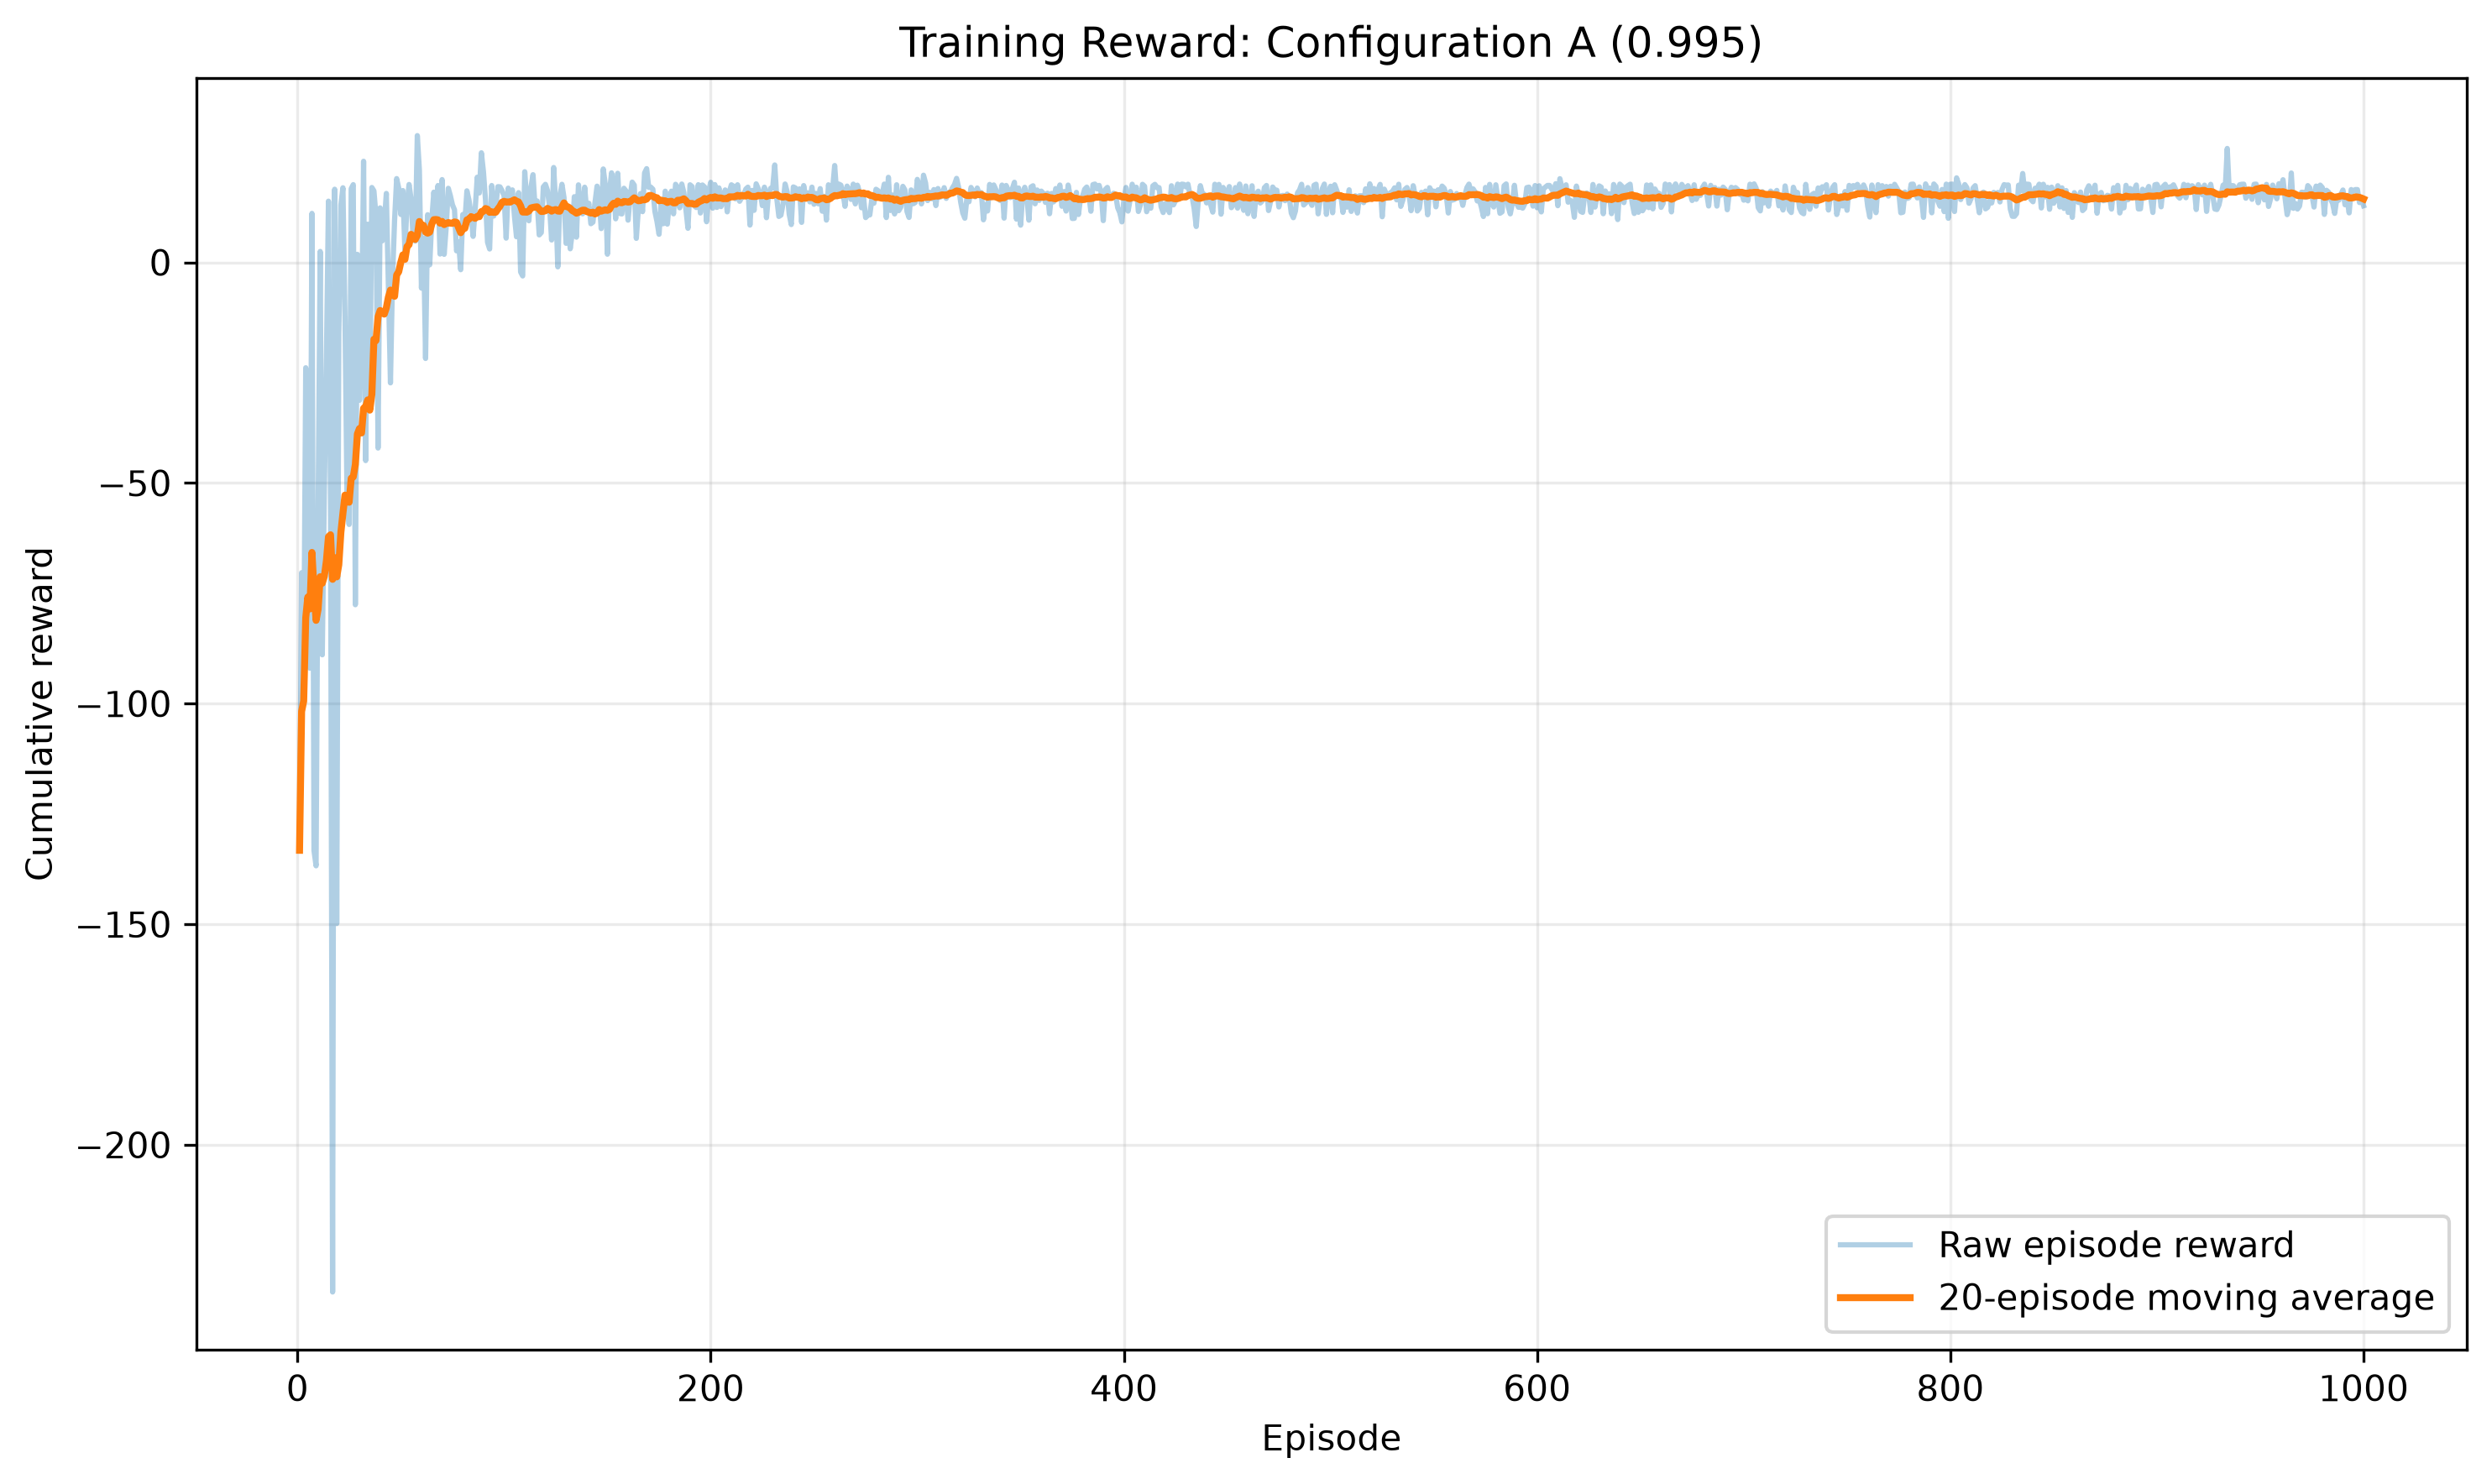

config_b_training_reward.png


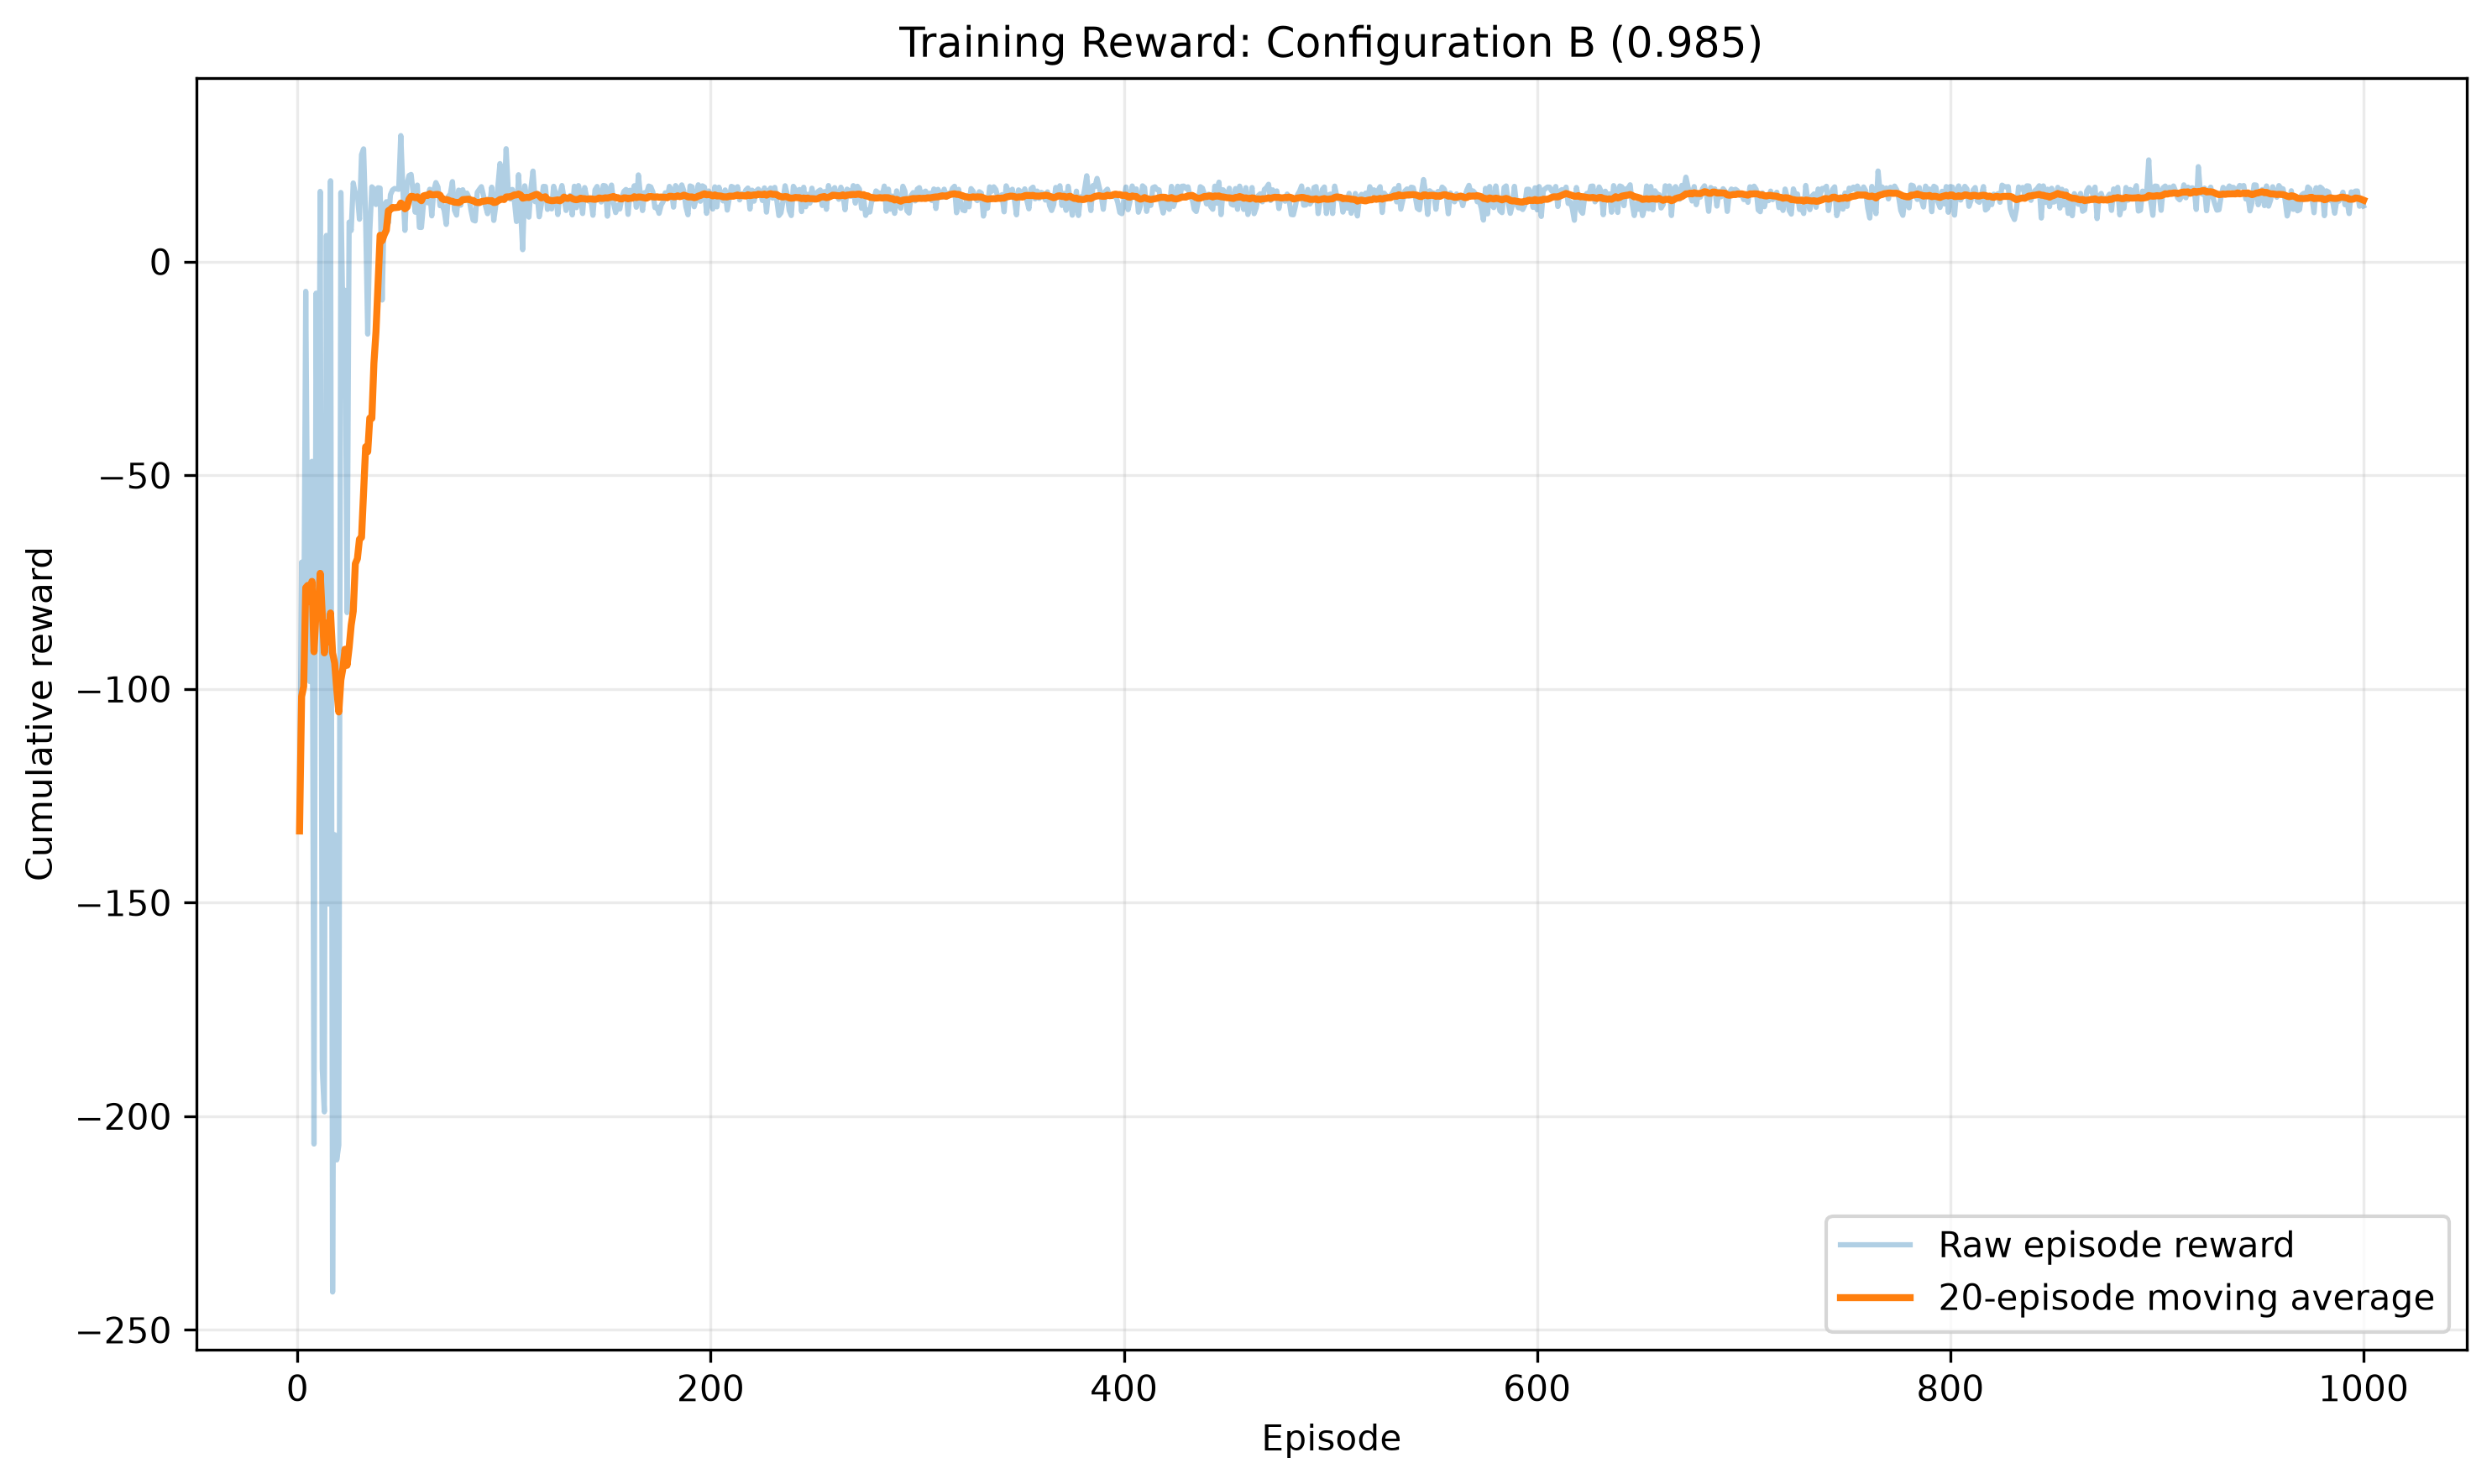

epsilon_decay_comparison.png


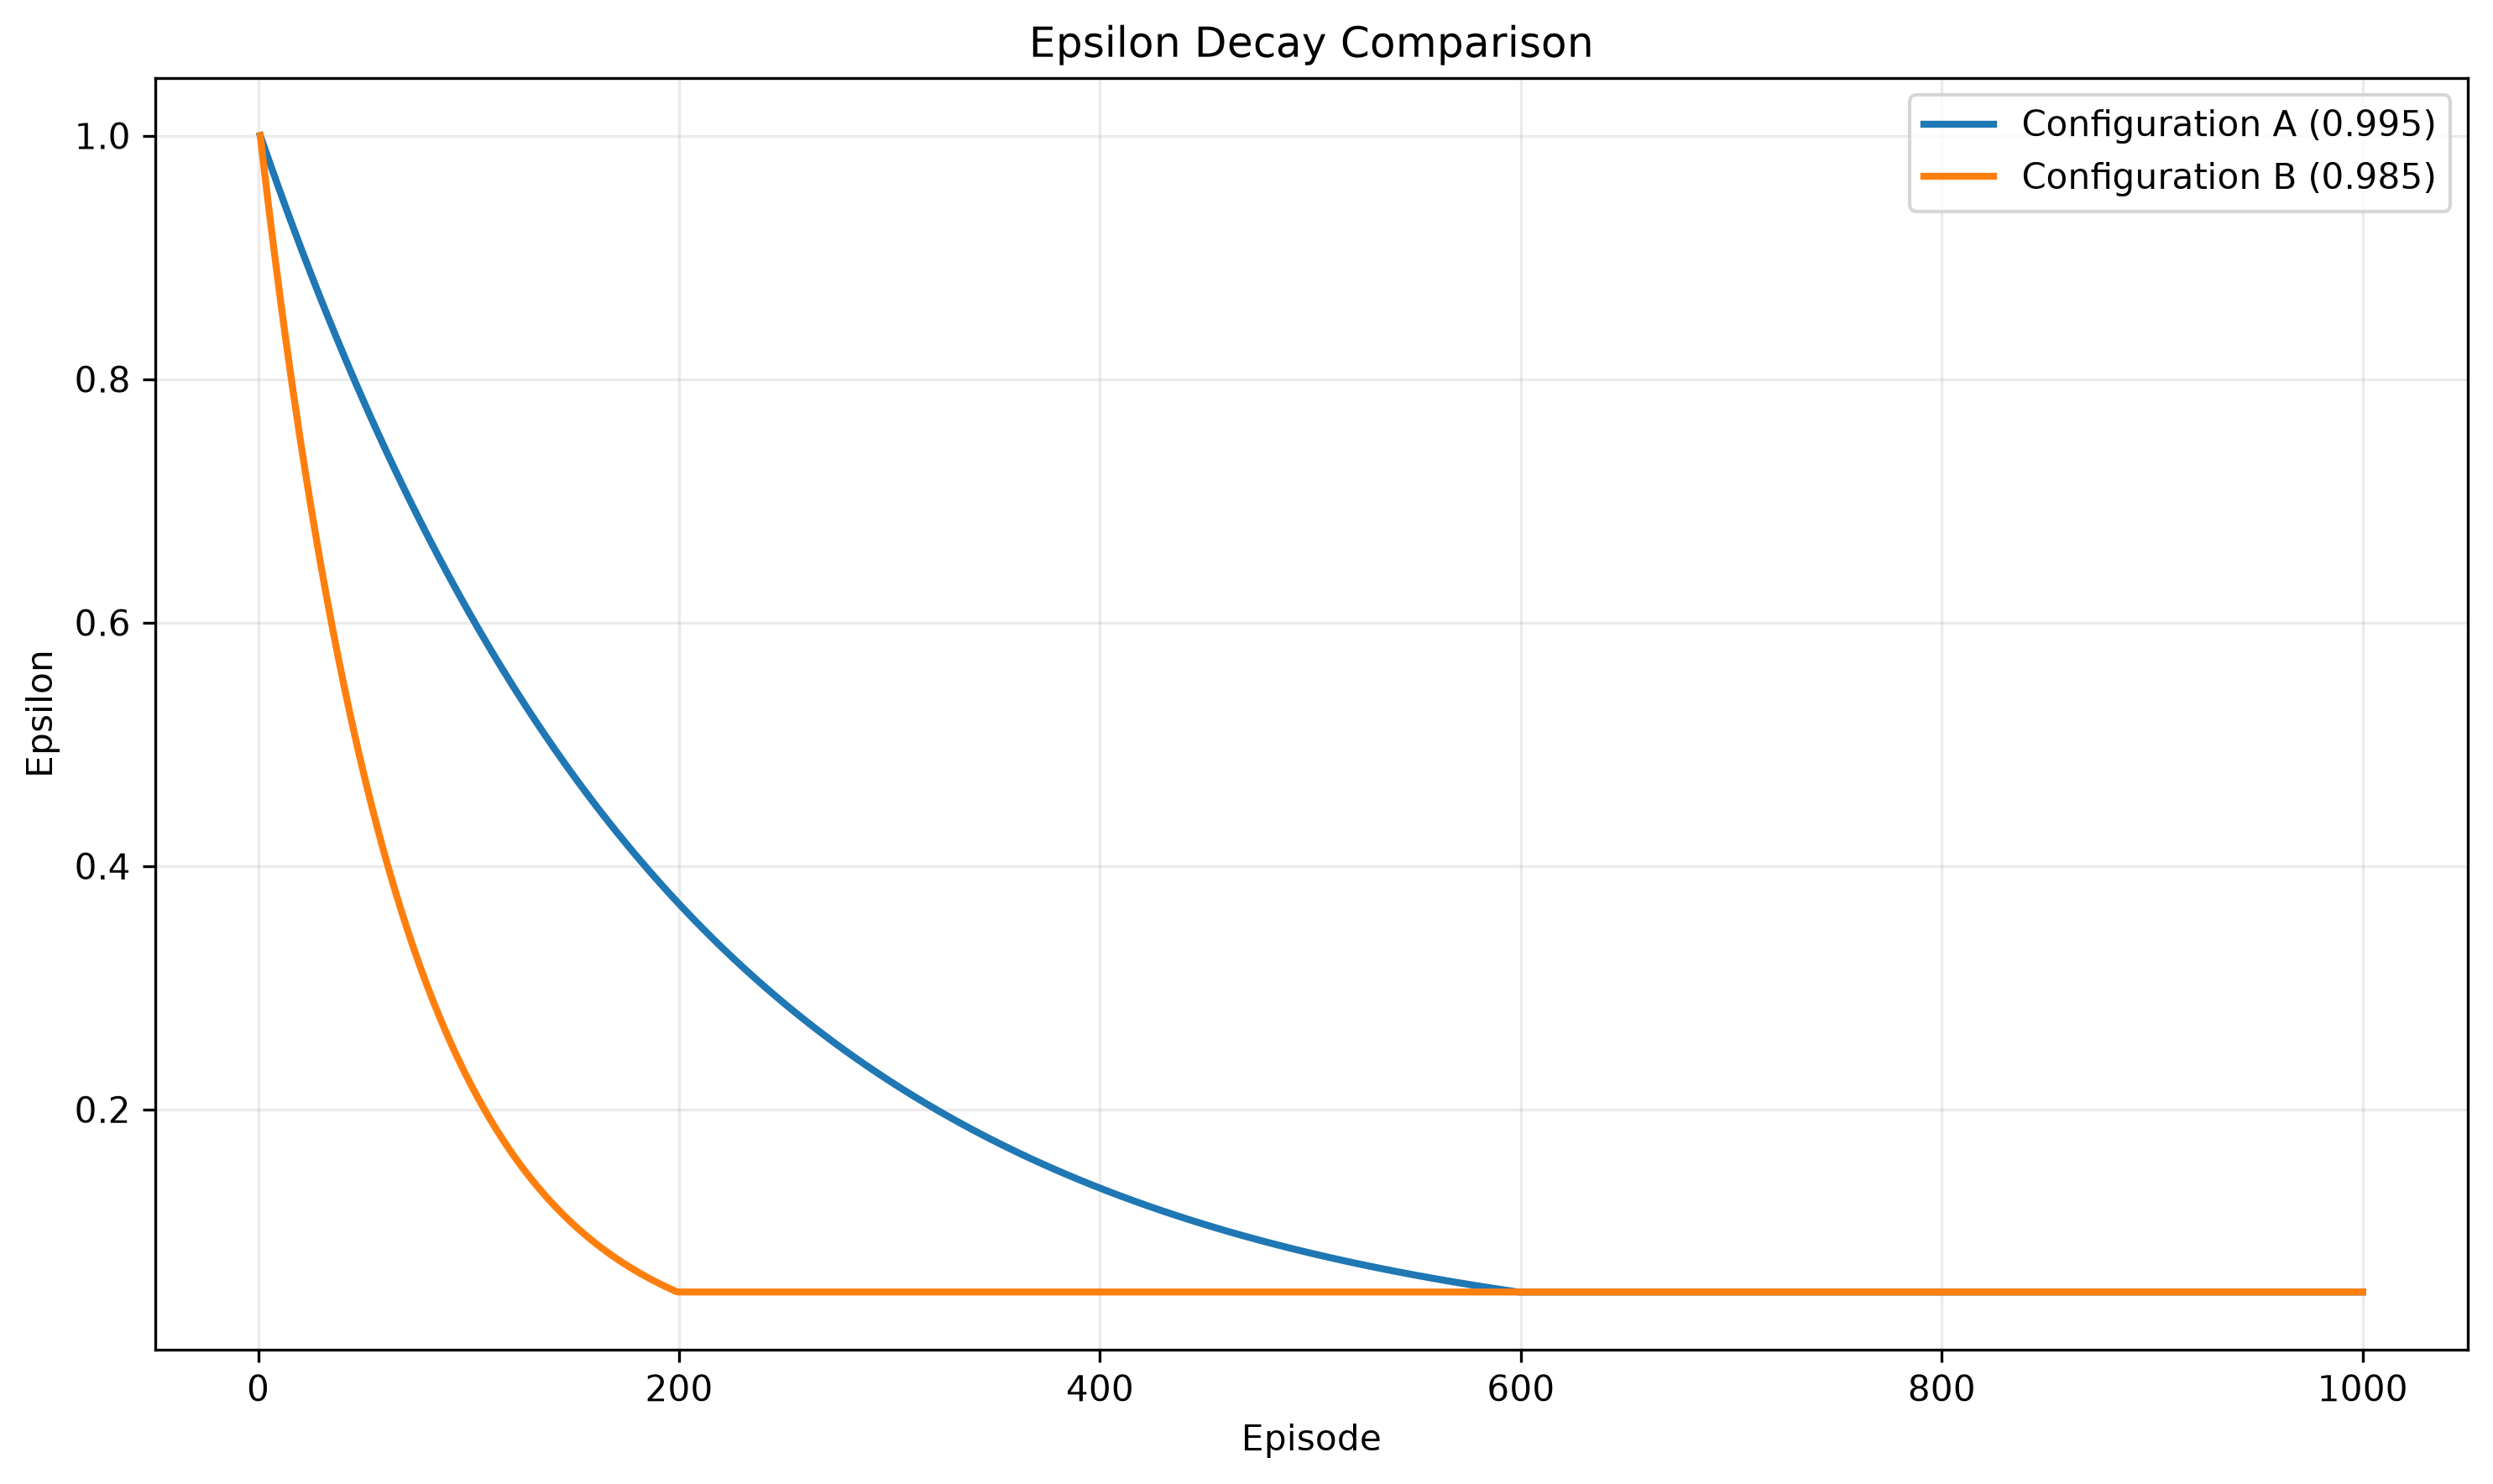

training_loss_comparison.png


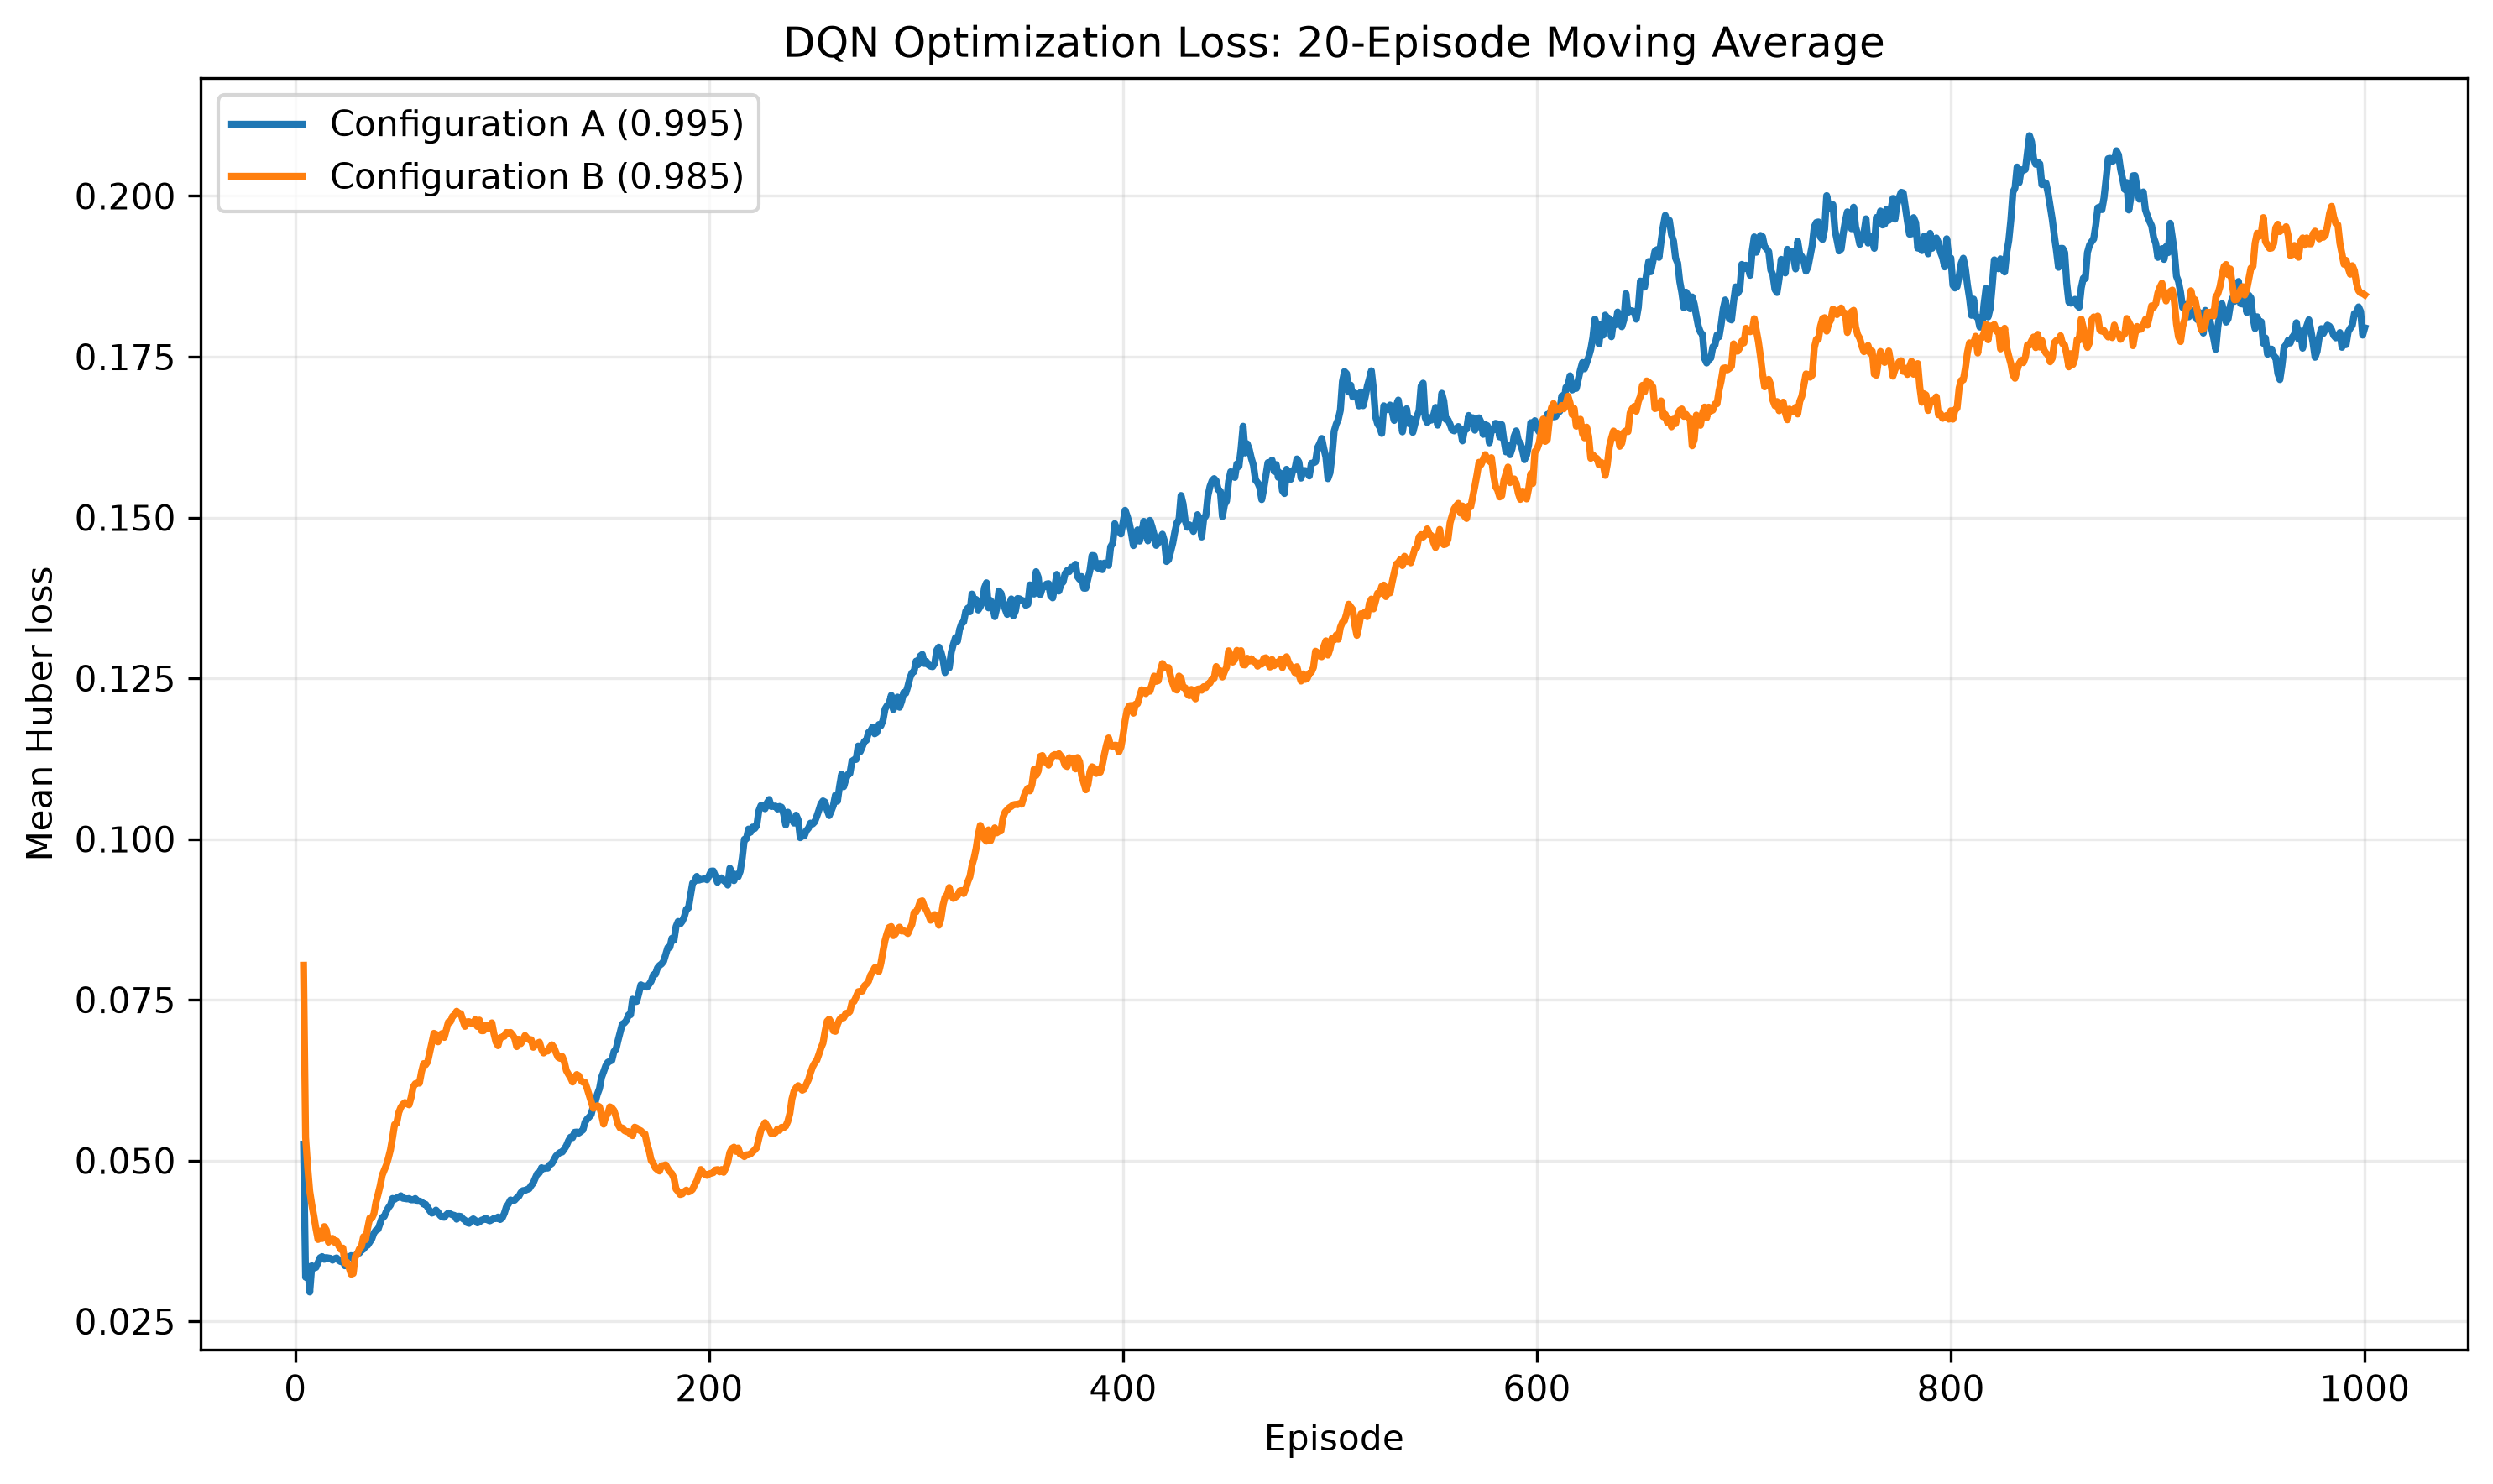

training_success_rate_comparison.png


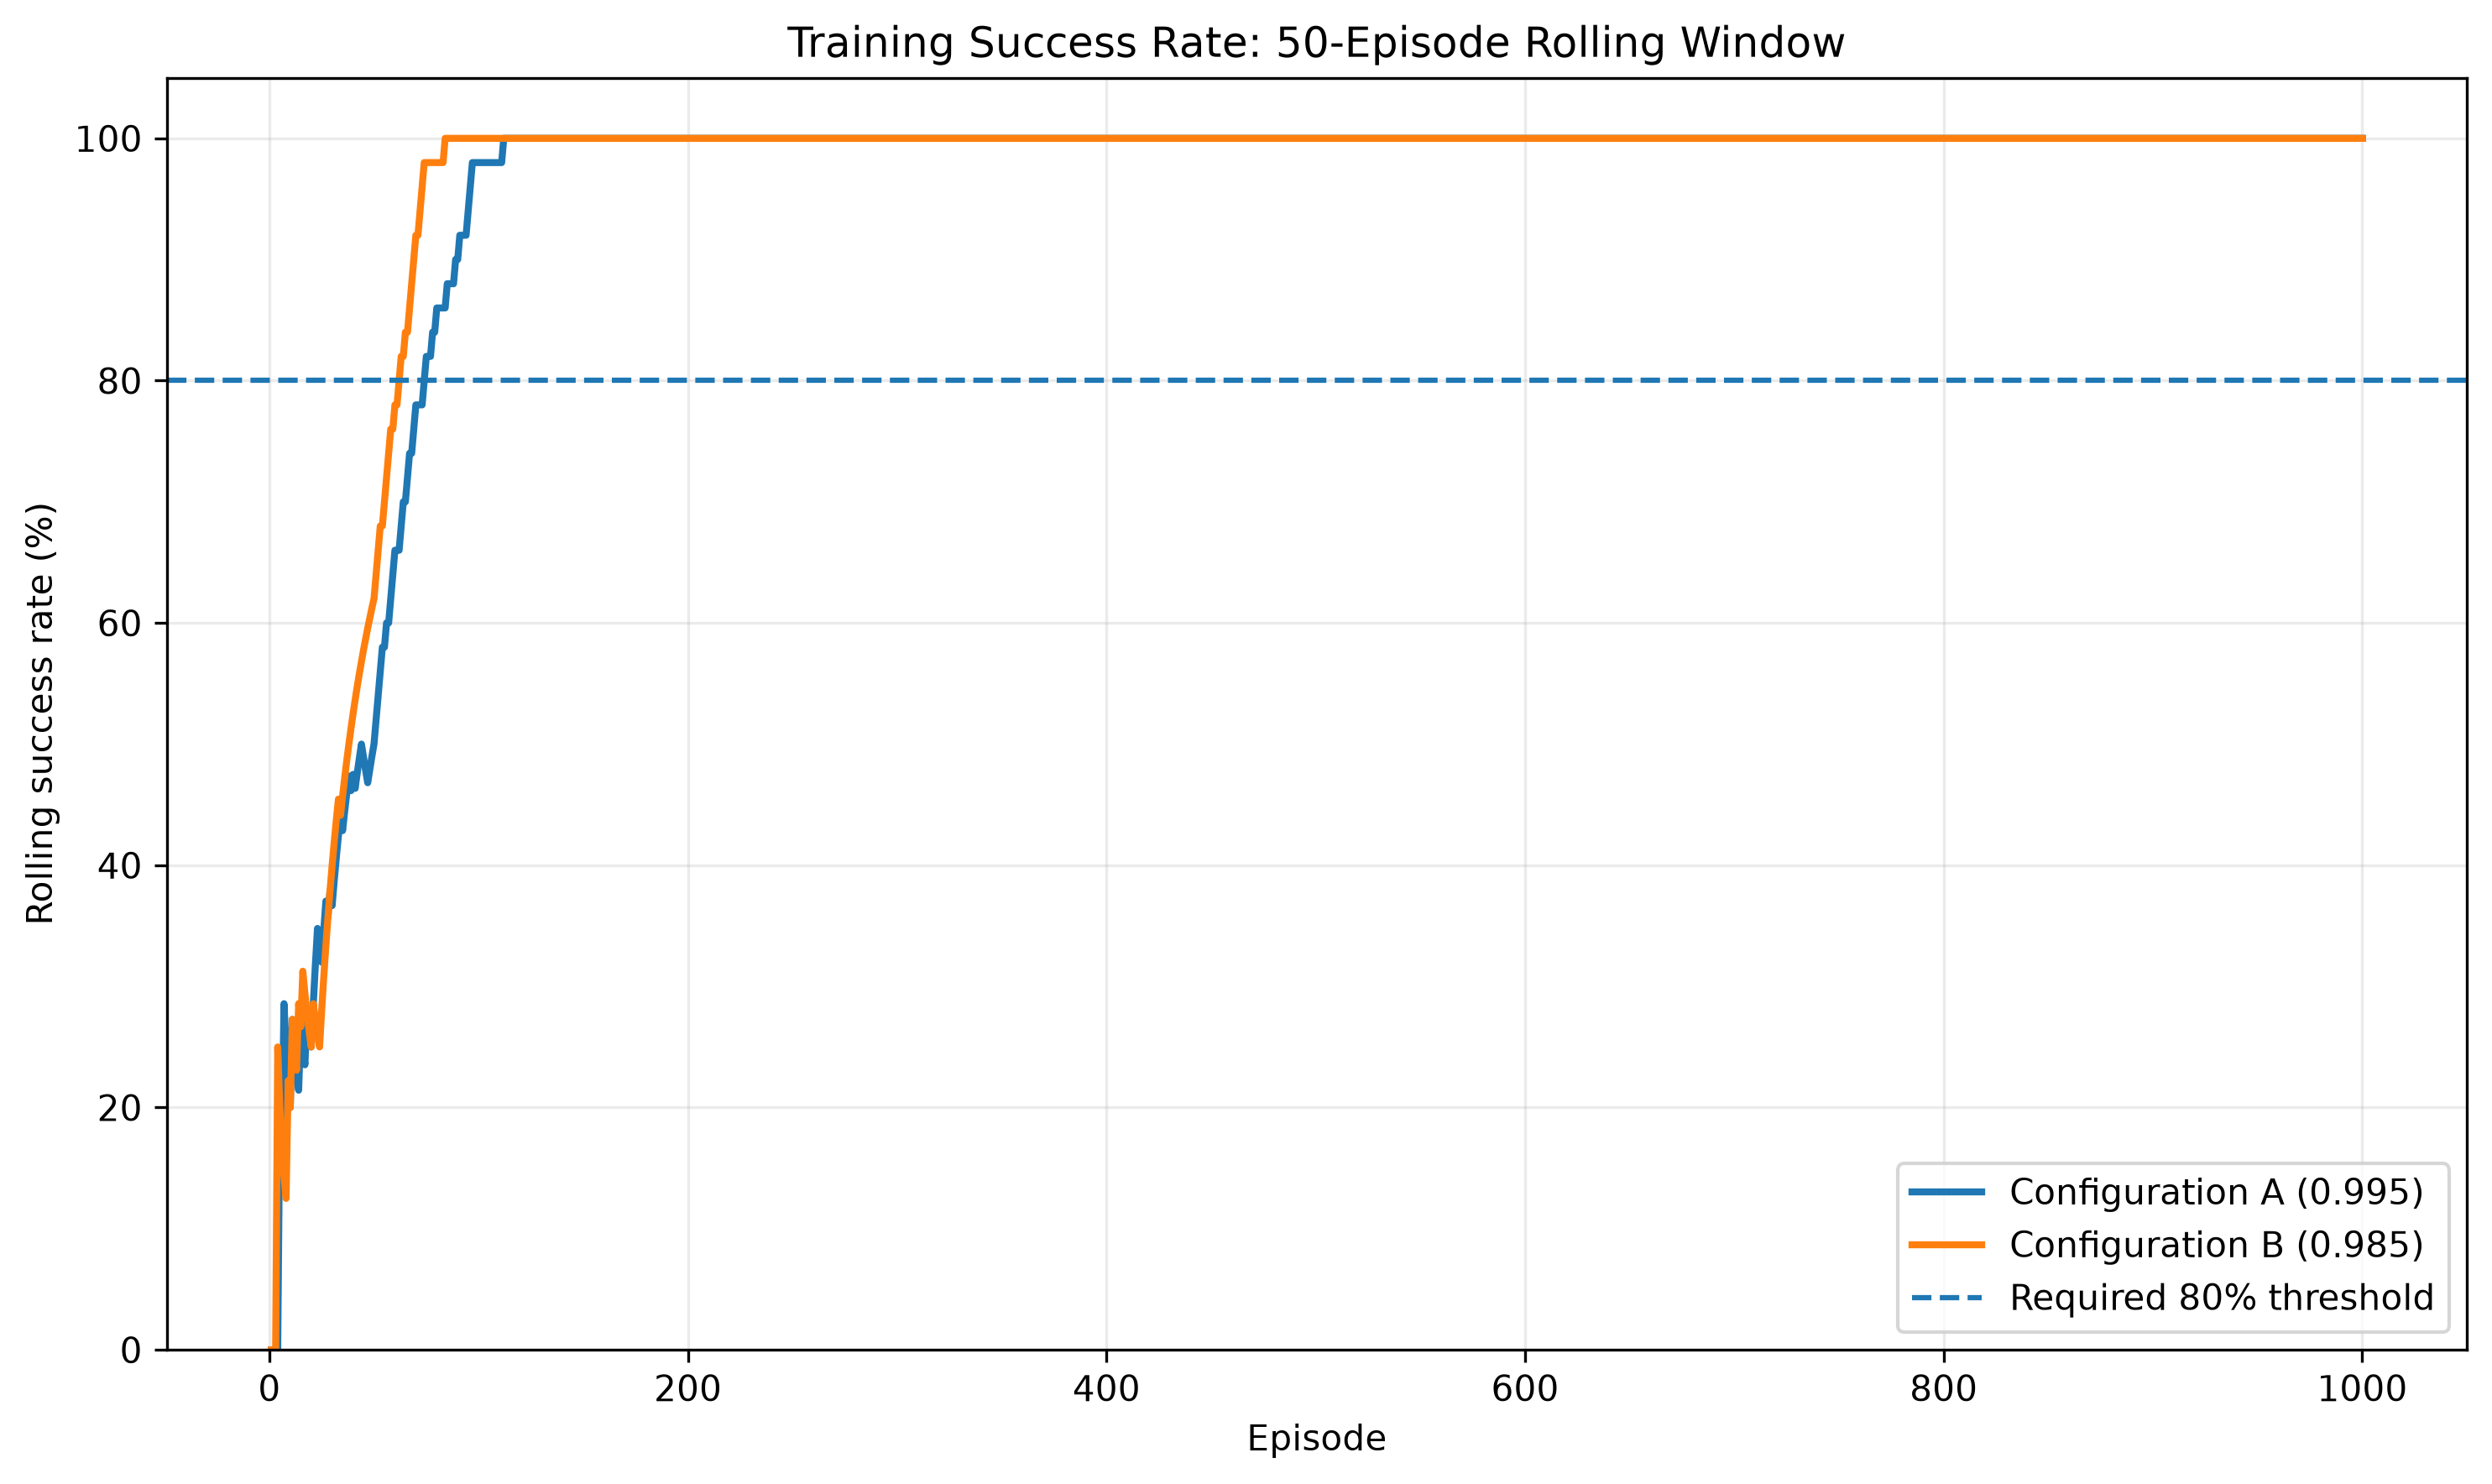

In [7]:
plot_paths = [
    "results/plots/config_a_training_reward.png",
    "results/plots/config_b_training_reward.png",
    "results/plots/epsilon_decay_comparison.png",
    "results/plots/training_loss_comparison.png",
    "results/plots/training_success_rate_comparison.png",
]

for relative_path in plot_paths:
    path = ROOT / relative_path
    if path.exists():
        print(path.name)
        display(Image(filename=str(path)))
    else:
        print("Missing plot:", relative_path)


## 6. Fixed-Goal Evaluation

The learned policies were evaluated without exploration on four benchmark targets:

\[
-0.8,\ -0.4,\ 0.4,\ 0.8
\]

Five episodes were run per target, giving 20 evaluation episodes per policy. The rule-based controller was evaluated on the same benchmark.


In [8]:
evaluation_rows = []

for label, path in [
    ("DQN Configuration A", "results/config_a/evaluation_summary.json"),
    ("DQN Configuration B", "results/config_b/evaluation_summary.json"),
    ("Rule-based baseline", "results/rule_based/evaluation_summary.json"),
]:
    data = load_json(path)
    overall = data.get("overall", {})
    row = {"policy": label}
    row.update(overall)
    evaluation_rows.append(row)

evaluation_table = pd.DataFrame(evaluation_rows)
display(evaluation_table)


,policy,episodes,successes,success_rate,mean_cumulative_reward,mean_episode_length,mean_final_absolute_error,mean_hold_actions,mean_action_changes
0,DQN Configuration A,20,20,1.0,13.179635,19.50,0.011630,4.75,6.50
1,DQN Configuration B,20,20,1.0,13.158829,19.75,0.012681,4.50,6.25
2,Rule-based baseline,20,20,1.0,12.866629,24.00,0.012209,16.50,1.00


### Final benchmark results

| Policy | Success | Mean reward | Mean episode length | Mean final absolute error | Mean HOLD actions | Mean action changes |
|---|---:|---:|---:|---:|---:|---:|
| DQN Configuration A | 20/20 | 13.1796 | 19.50 | 0.0116 | 4.75 | 6.50 |
| DQN Configuration B | 20/20 | 13.1588 | 19.75 | 0.0127 | 4.50 | 6.25 |
| Rule-based baseline | 20/20 | 12.8666 | 24.00 | 0.0122 | 16.50 | 1.00 |

All policies reached every benchmark target. The selected DQN policy completed episodes faster and obtained a higher mean reward than the rule-based controller. The rule-based policy used HOLD much more often, while the DQN policy made more frequent corrective action changes.


In [9]:
for relative_path in [
    "results/plots/configuration_comparison.csv",
    "results/plots/policy_comparison.csv",
]:
    path = ROOT / relative_path
    print(path.name)
    display(pd.read_csv(path))


configuration_comparison.csv


,configuration,epsilon_decay,training_episodes,training_time_seconds,final_epsilon,final_20_mean_training_reward,final_50_training_success_rate,evaluation_successes,evaluation_episodes,evaluation_success_rate,mean_evaluation_reward,mean_episode_length,mean_final_absolute_error,mean_hold_actions,mean_action_changes
0,Configuration A (0.995),0.995,1000,194.741324,0.05,14.361483,1.0,20,20,1.0,13.179635,19.50,0.011630,4.75,6.50
1,Configuration B (0.985),0.985,1000,144.219668,0.05,14.382342,1.0,20,20,1.0,13.158829,19.75,0.012681,4.50,6.25


policy_comparison.csv


,policy,successes,episodes,success_rate,mean_cumulative_reward,mean_episode_length,mean_final_absolute_error,mean_hold_actions,mean_action_changes
0,Selected DQN Config A,20,20,1.0,13.179635,19.50,0.011630,4.75,6.50
1,DQN Config B,20,20,1.0,13.158829,19.75,0.012681,4.50,6.25
2,Rule-based policy,20,20,1.0,12.866629,24.00,0.012209,16.50,1.00


dqn_configuration_evaluation_reward.png


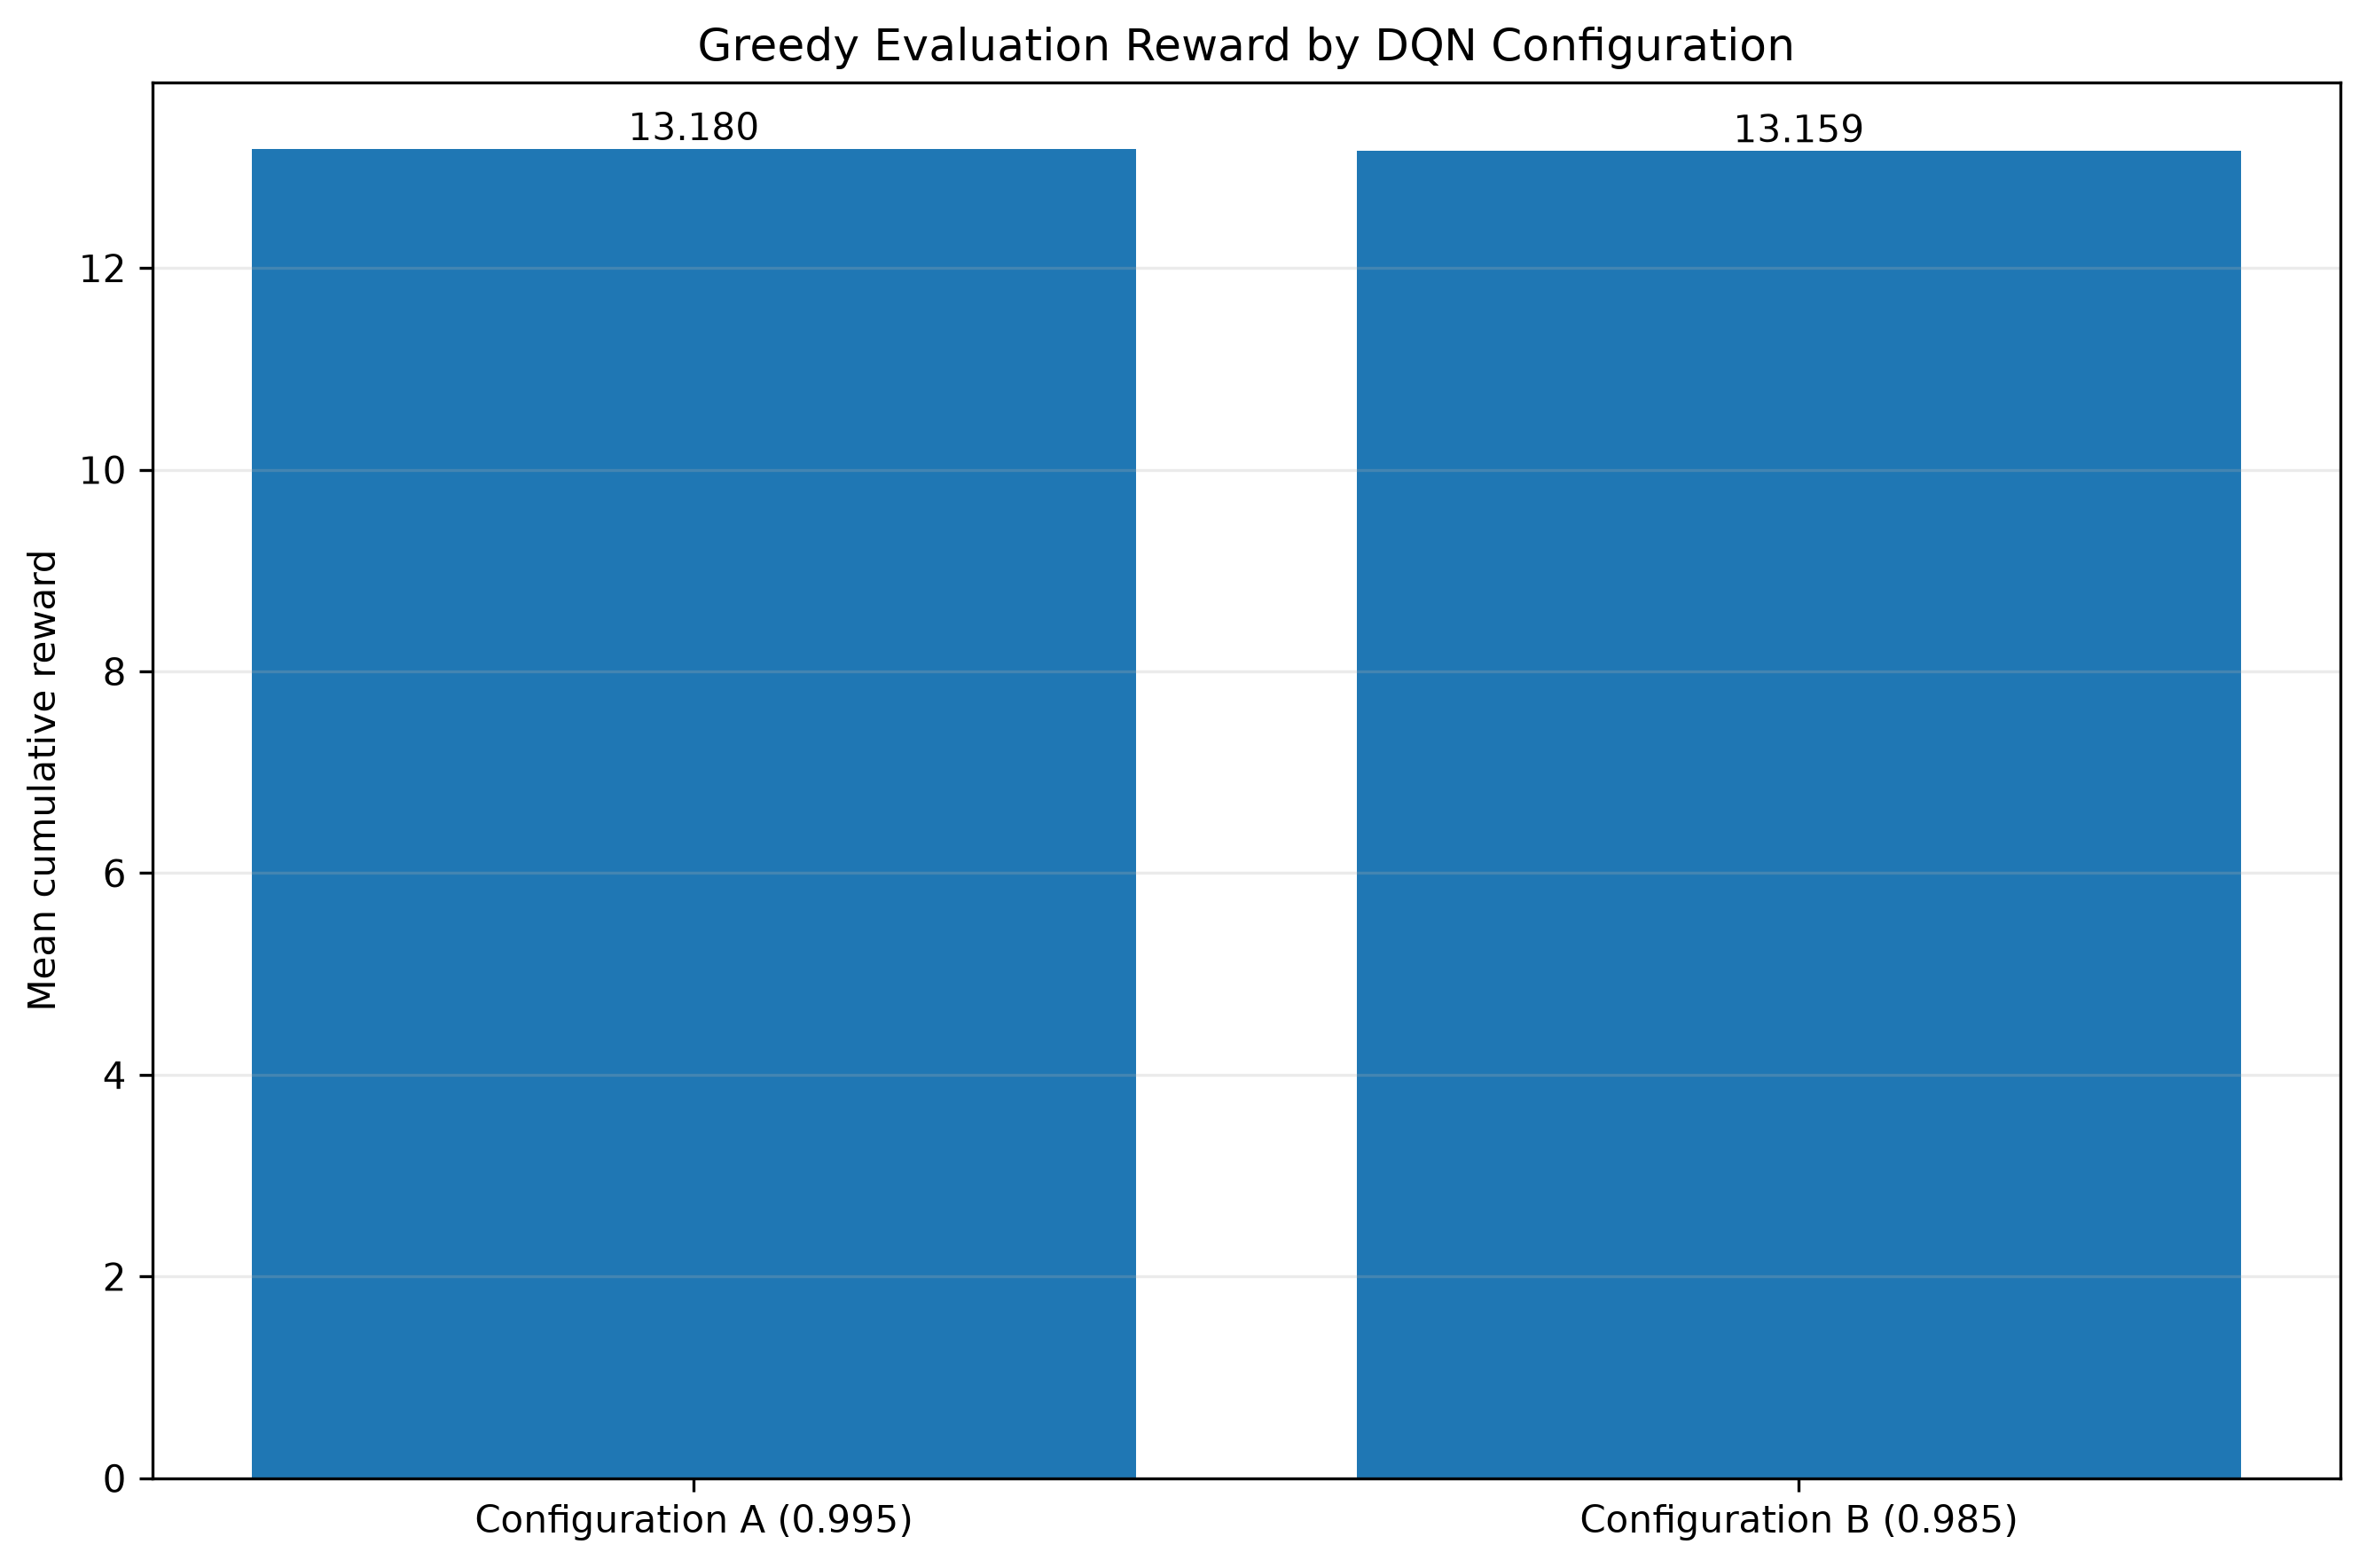

evaluation_success_rate_by_goal.png


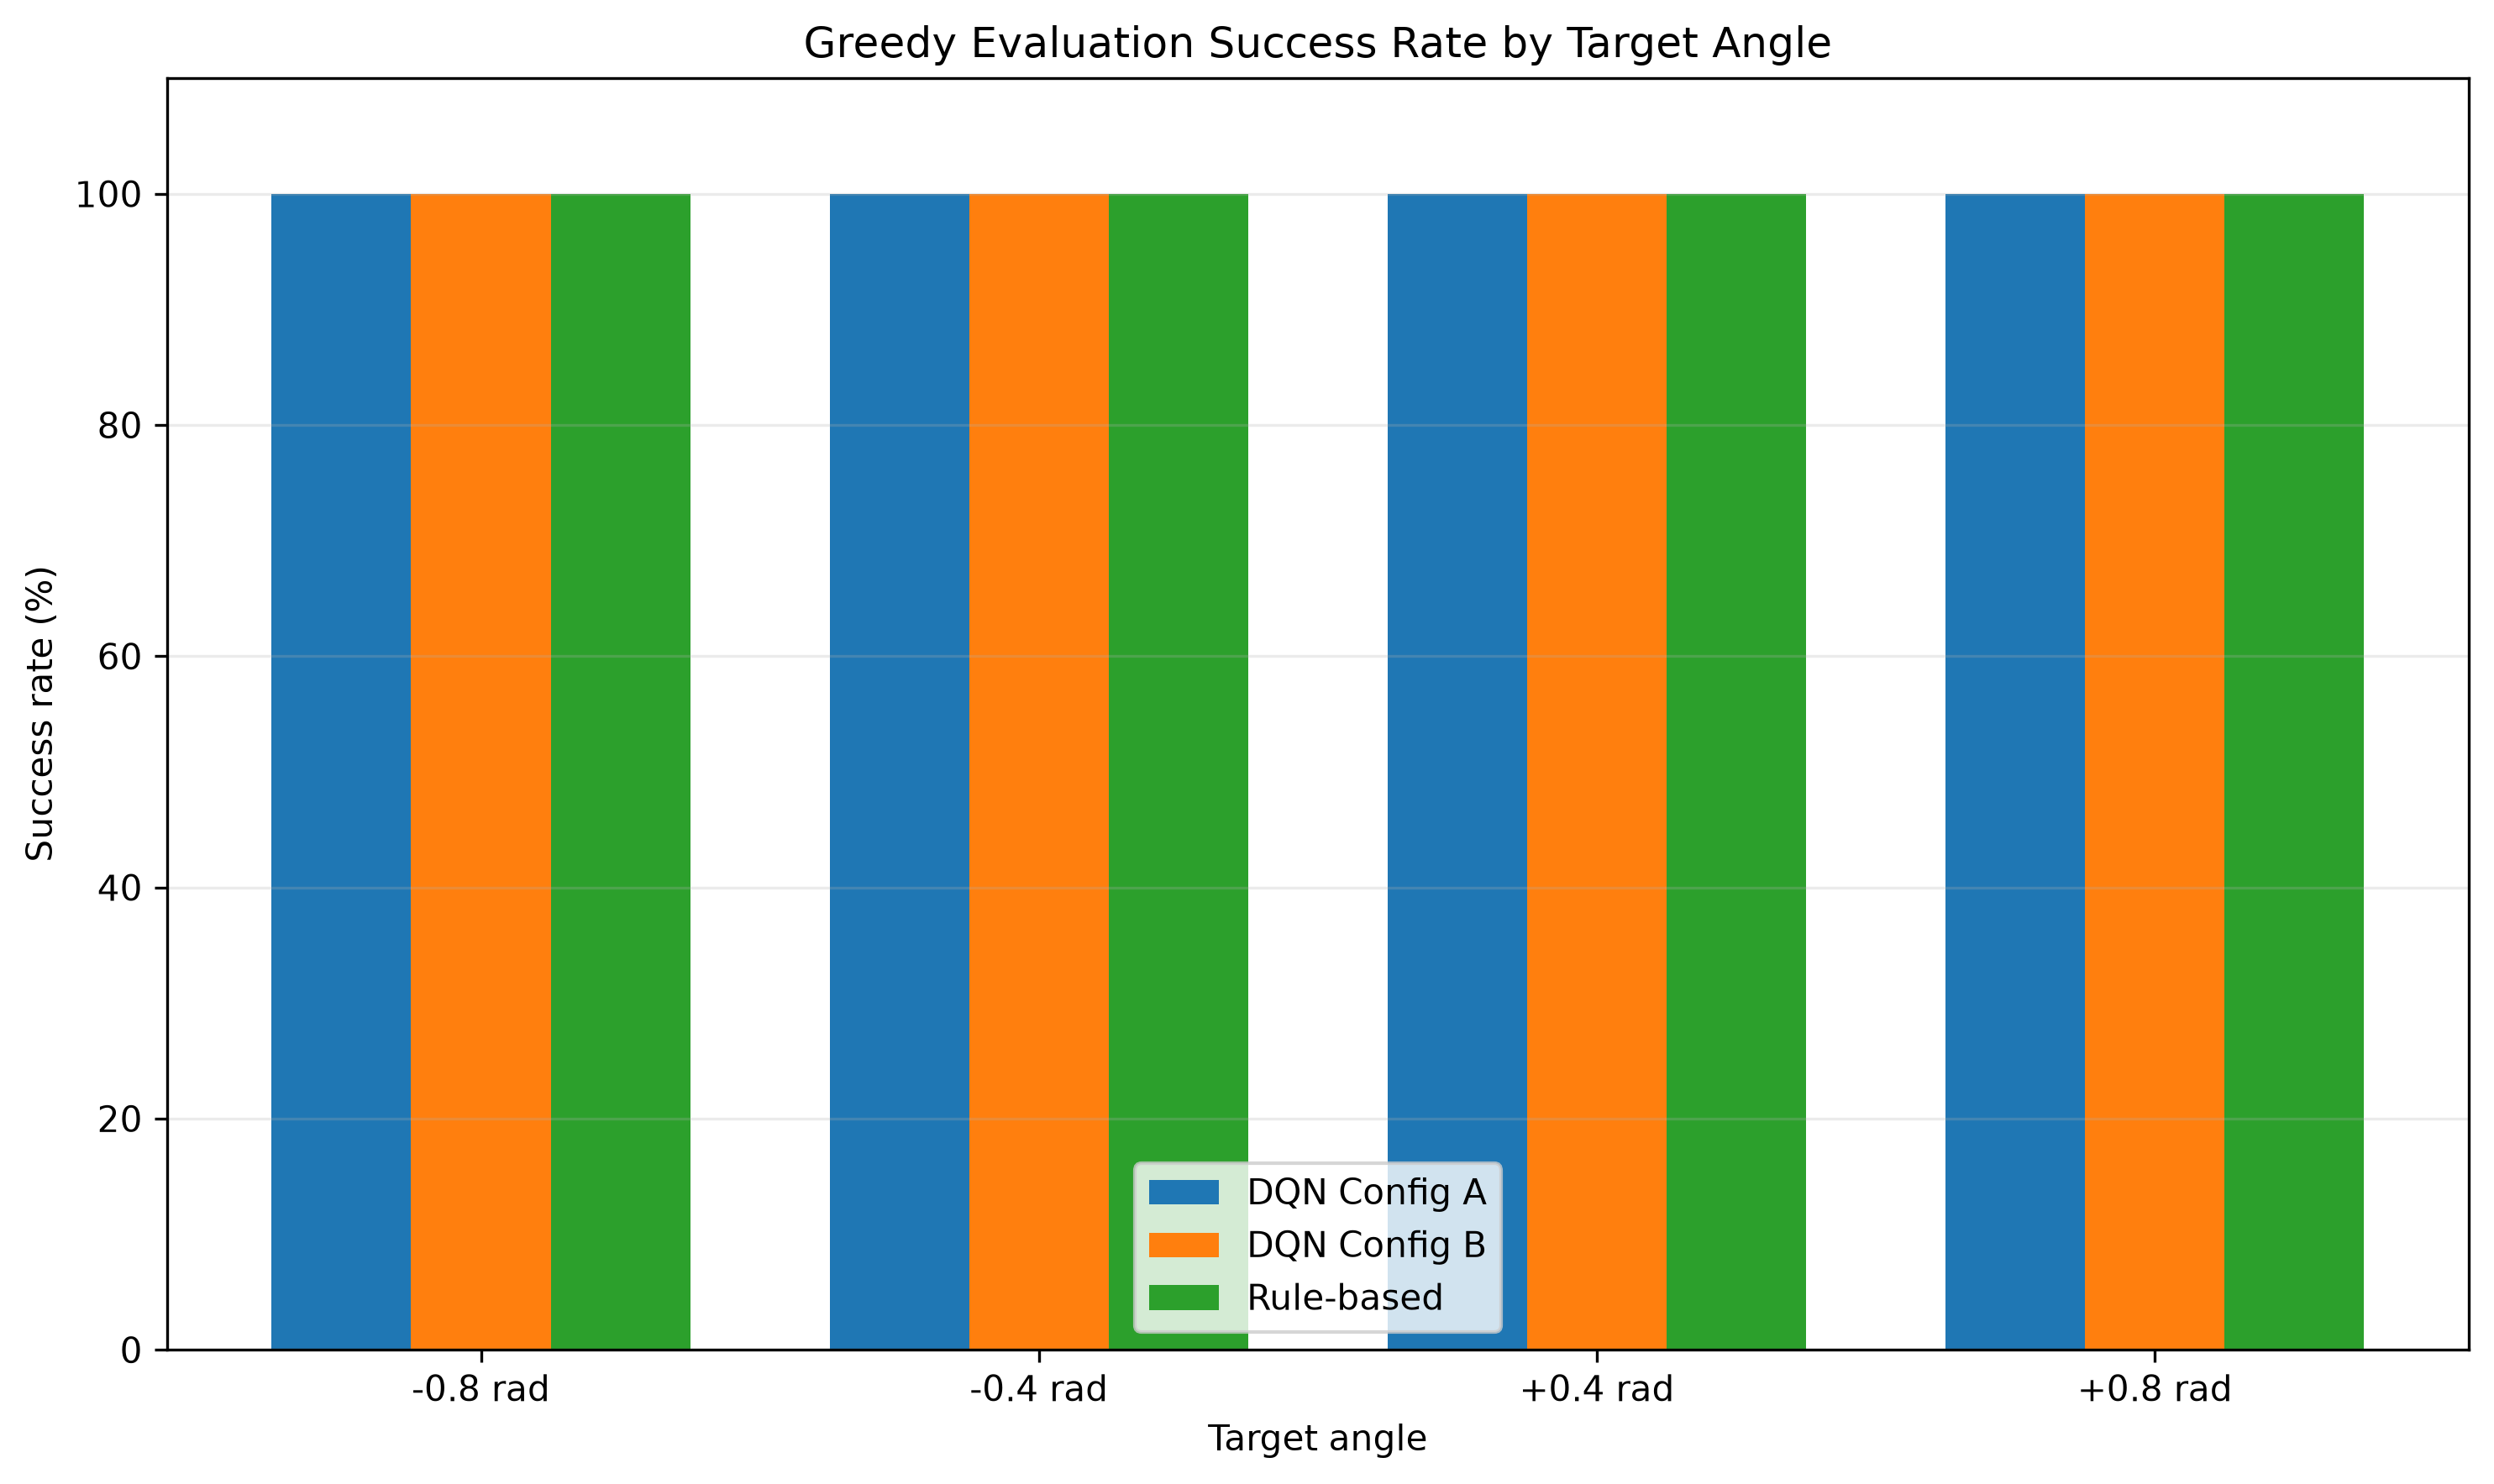

policy_episode_length_comparison.png


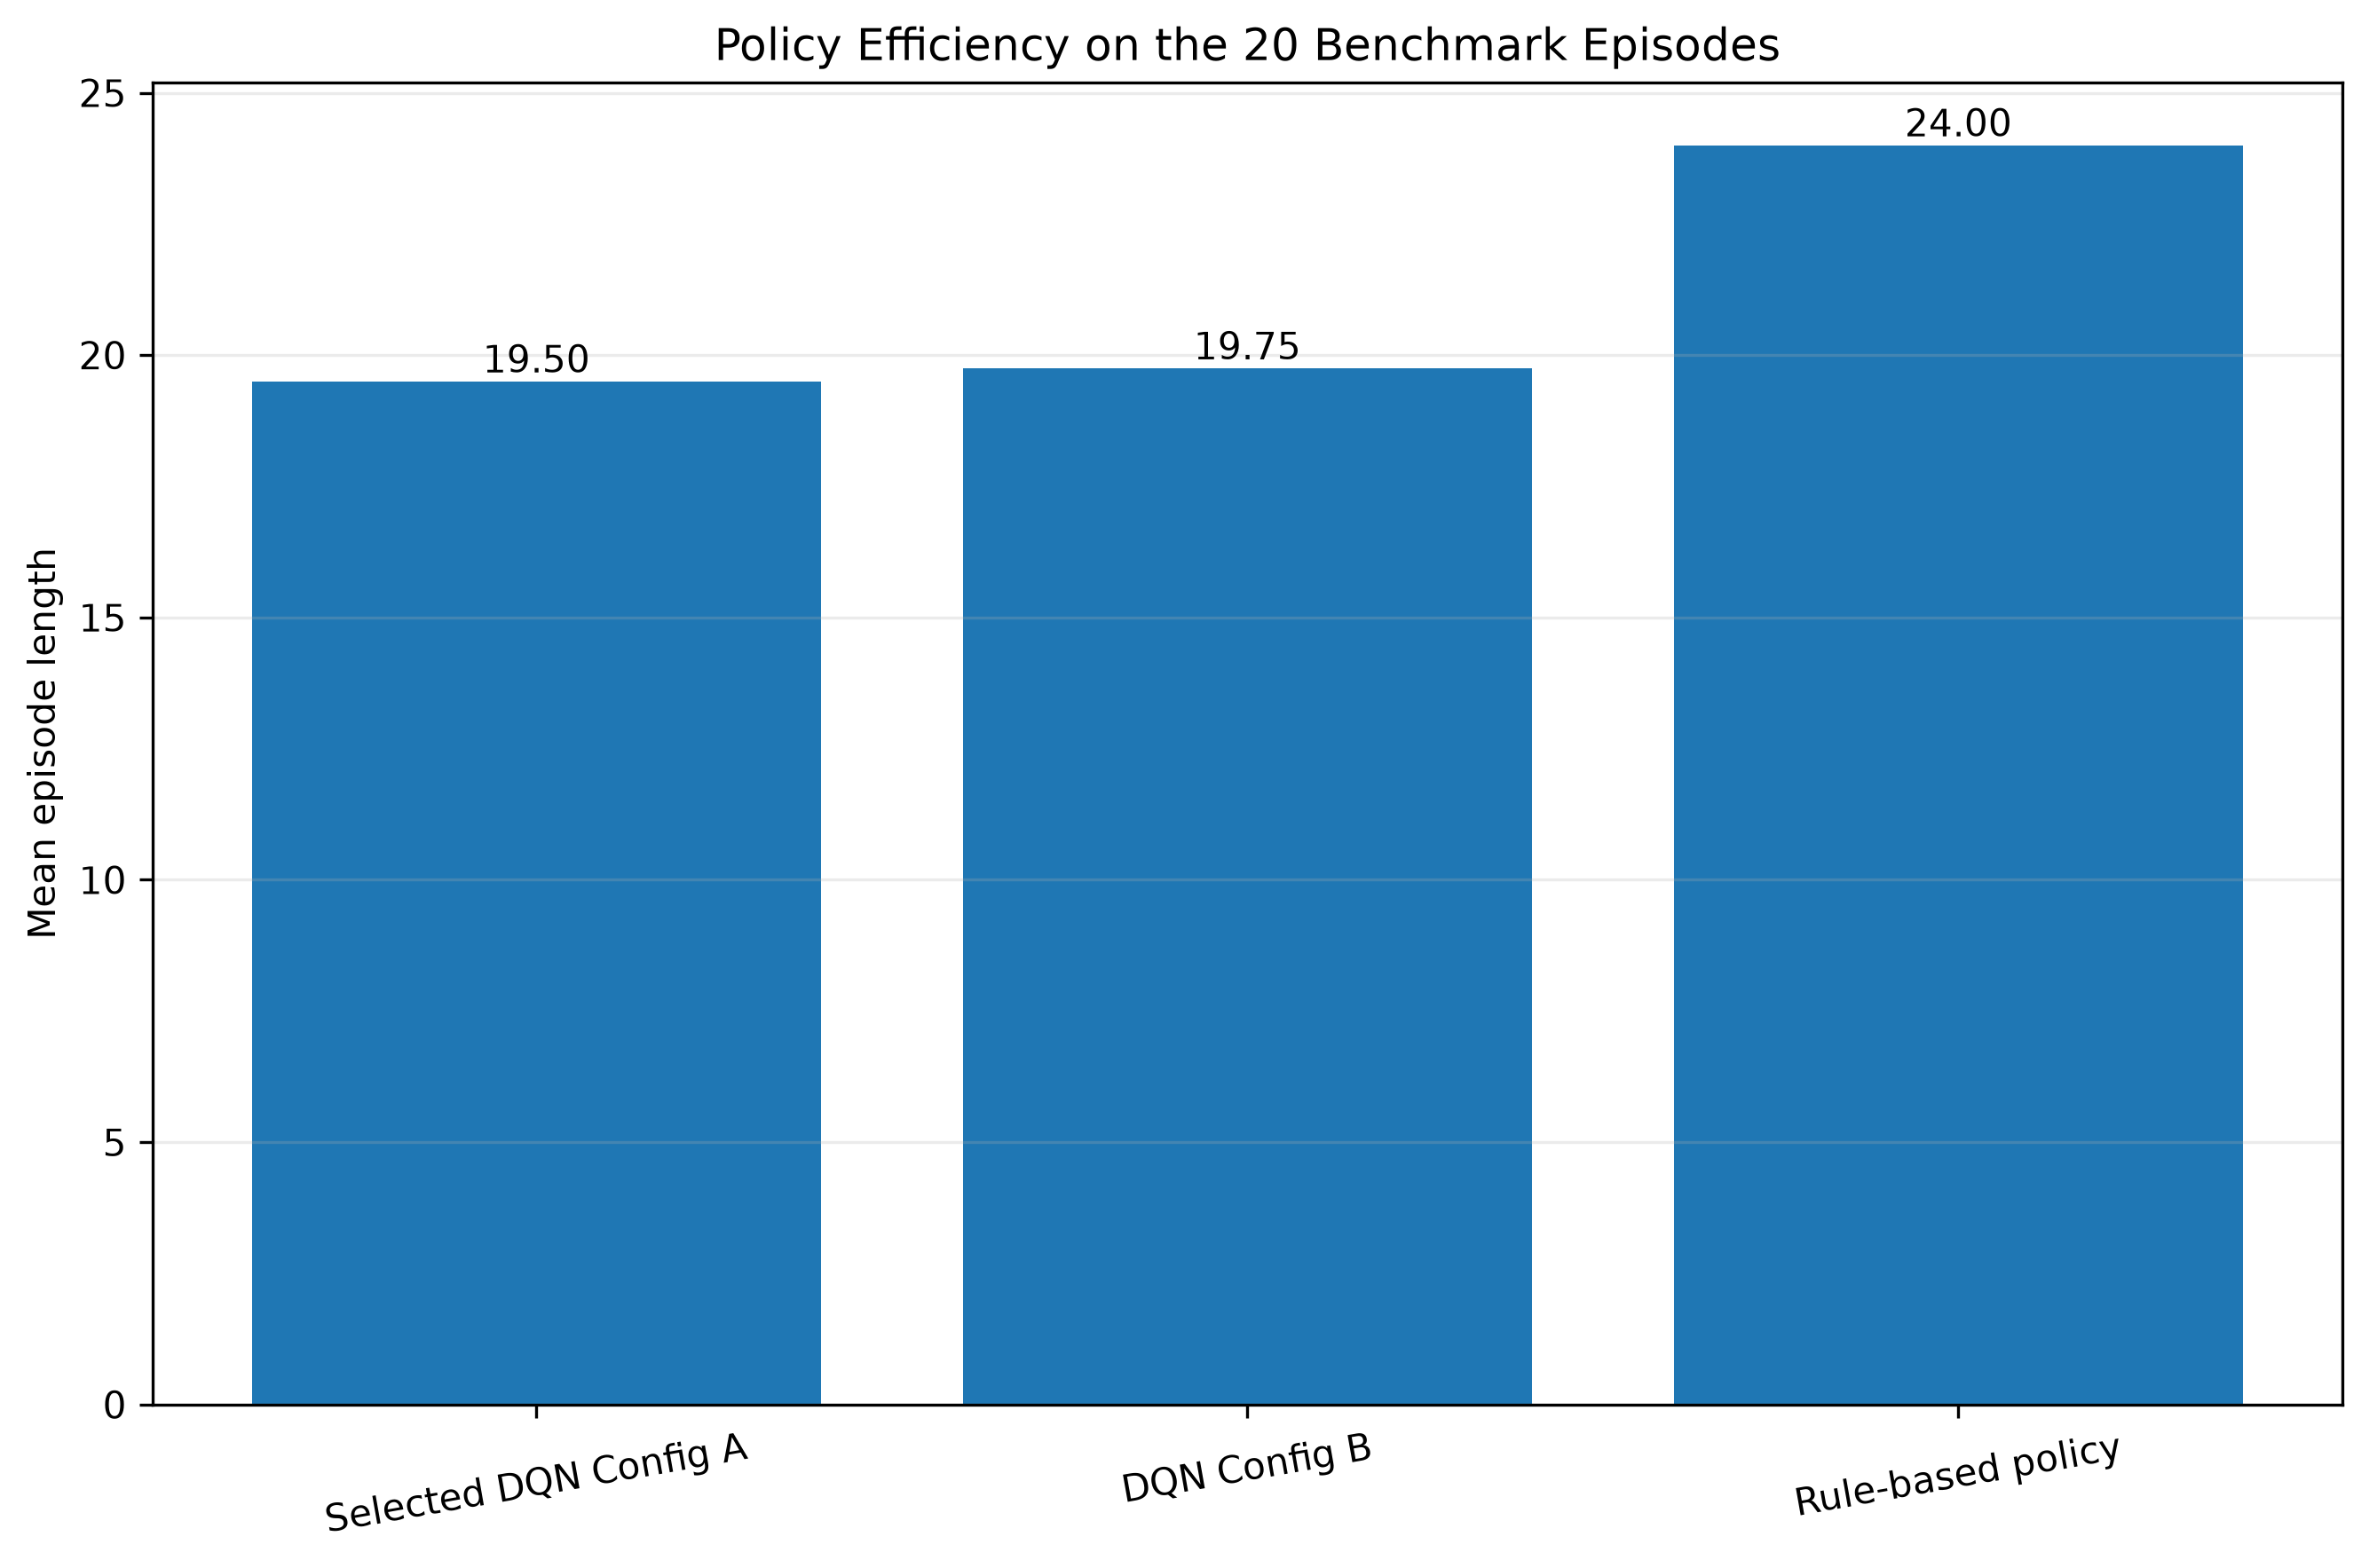

In [10]:
for relative_path in [
    "results/plots/dqn_configuration_evaluation_reward.png",
    "results/plots/evaluation_success_rate_by_goal.png",
    "results/plots/policy_episode_length_comparison.png",
]:
    path = ROOT / relative_path
    if path.exists():
        print(path.name)
        display(Image(filename=str(path)))


## 7. Selected Checkpoint Verification

`models/selected_dqn.pt` is the final selected Configuration A checkpoint used by the evaluation and rendering commands.


In [11]:
checkpoint_path = ROOT / "models/selected_dqn.pt"

digest = hashlib.sha256(checkpoint_path.read_bytes()).hexdigest()
print("Checkpoint:", checkpoint_path)
print("Size:", checkpoint_path.stat().st_size, "bytes")
print("SHA-256:", digest)

checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
print("Loaded object type:", type(checkpoint).__name__)

if isinstance(checkpoint, dict):
    print("Top-level keys:", sorted(map(str, checkpoint.keys())))
else:
    print("Checkpoint loaded successfully.")


Checkpoint: /mnt/c/Users/DELL/OneDrive - Durham College/Desktop/REINFORCEMENT LEARNING - DAVID/Unitree_MuJoCo_G1_Primer_Workshop/models/selected_dqn.pt
Size: 94345 bytes
SHA-256: e7014142bbcdf4e6a5c946cf2449c6fd6c1236ef8a682430eb4cbf7efd143c60


Loaded object type: dict
Top-level keys: ['action_dim', 'agent_random_state', 'config', 'epsilon', 'observation_dim', 'online_network', 'optimization_steps', 'optimizer', 'target_network', 'torch_random_state']


## 8. Exact Reproduction Commands

Run all commands from the repository root after activating the virtual environment.

### Start the completed assignment notebook

```bash
jupyter notebook CSCN8020_Assignment3.ipynb
```

### Train Configuration A

```bash
PYTHONPATH=src python src/train_dqn.py --name config_a --epsilon-decay 0.995 --episodes 1000 --seed 42
```

### Train Configuration B

```bash
PYTHONPATH=src python src/train_dqn.py --name config_b --epsilon-decay 0.985 --episodes 1000 --seed 42
```

### Evaluate selected Configuration A

```bash
PYTHONPATH=src python src/evaluate_dqn.py --policy dqn --checkpoint models/selected_dqn.pt --name config_a --seed 42
```

### Evaluate Configuration B

```bash
PYTHONPATH=src python src/evaluate_dqn.py --policy dqn --checkpoint models/config_b_final.pt --name config_b --seed 42
```

### Evaluate the rule-based baseline

```bash
PYTHONPATH=src python src/evaluate_dqn.py --policy rule_based --name rule_based --seed 42
```

### Render the selected trained policy

```bash
PYTHONPATH=src python src/render_dqn_policy.py --checkpoint models/selected_dqn.pt --goals -0.8 0.8 --seed 42 --countdown 3 --step-delay 0.08
```


## 9. Interpretation

The two DQN configurations solved the elbow-targeting task reliably. The faster epsilon decay in Configuration B reduced training time, while the slower decay in Configuration A provided a marginally better evaluation reward, shorter average episode length, and lower final absolute error. The comparison demonstrates that exploration scheduling can affect the quality and efficiency of the final policy even when both runs reach a 100% success rate.

The rule-based controller remained stable and interpretable, but it was more conservative. Its larger HOLD count and longer episodes indicate that it approached targets with fewer action changes but less time efficiency.


## 10. Responsible AI Disclosure

AI tools were used for explanation, debugging support, formatting assistance, and review. The environment design, DQN implementation, experiments, evaluation decisions, interpretation, repository organization, and final submission were reviewed and validated by Emmanuel Ihejiamaizu. No external reinforcement-learning framework was used to replace the student-written DQN algorithm.


## 11. Conclusion

The assignment successfully converts the validated Unitree G1 elbow controller into a Gymnasium reinforcement-learning environment and trains a student-written DQN to control the left elbow across multiple target angles. The selected model achieved 100% benchmark success, outperformed the rule-based baseline in mean reward and episode length, and is provided with reproducible code, saved metrics, plots, a trained checkpoint, reports, and a rendered demonstration video.
